# Age prediction from single-cell PBMC data with `patpy`

This tutorial benchmarks six sample-representation methods on the task of
**predicting biological age from PBMC scRNA-seq profiles**, then validates
the biological conclusions on an independent cohort, and finally cracks
open one of the supervised models (SampleCLR) to read the per-cell
attention weights that drive its age prediction.

The methods cover the four flavours of sample-level analysis exposed by
`patpy`:

- **Pseudobulk** (`patpy.tl.Pseudobulk`) — mean of cell embeddings per donor.
- **Cell-group composition with CLR** (`patpy.tl.CellGroupComposition`) — the
  fractions of every cell type in a donor, centred-log-ratio transformed.
- **GloScope** (`patpy.tl.GloScope_py`) — KL-divergence between donor-level
  cell-state distributions.
- **SampleCLR** ([package](https://github.com/lueckenlab/SampleCLR)) — a
  contrastive sample-level model with a self-supervised + supervised stage.
- **PaSCient** (`patpy.tl.PaSCient`) — cell→patient attention model.
- **MixMIL** (`patpy.tl.MixMIL`) — mixed-model multiple-instance learning.

We run them on the **AIFI Immunobiology of Aging** cohort (234 donors,
ages 40–89, 3.76 M PBMCs across 17 sequencing batches) and validate on
**OneK1K** (981 donors, ages 19–97).

Two questions:

1. **Engineering:** which sample representation best preserves age signal
   while not encoding the sequencing batch?
2. **Biology:** what changes in immune composition / per-cell-type
   transcription are reproducible across cohorts, and what genes drive
   the age signal inside the cell types the model pays the most
   attention to?

The notebook is self-contained — every fit, score and figure comes
from running its own cells. On a single CPU core a full pass takes
30–60 minutes; PaSCient finishes much faster on a GPU.

## Setup

Set ``SMOKE = True`` to iterate on a 20-donor × 200-cell subset (good
for debugging). The full run uses all donors and caps slow methods at
500 cells/donor.

In [1]:
%load_ext autoreload
%autoreload 2
import gc, json, time, warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

import patpy

warnings.filterwarnings("ignore", category=UserWarning)

# Plotting defaults: no grid, despine top + right, frameless UMAPs.
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sc.set_figure_params(dpi=80, frameon=False)

def despine(*axes):
    """Drop the top/right spines on every axis passed in."""
    for ax in axes:
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.grid(False)

def style_umap(ax):
    """Strip frame + ticks from an embedding scatter."""
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

SEED = 42
print("patpy", patpy.__version__, " · torch.cuda.is_available()", torch.cuda.is_available())

patpy 0.16.5  · torch.cuda.is_available() True


In [2]:
# Quick-iteration flag. Set to True for a 20-donor × 200-cell sanity loop.
SMOKE = False

# Capped sample size per donor for the slow methods (GloScope / SampleCLR /
# PaSCient / MixMIL). Pseudobulk + composition use all cells.
N_CELLS_PER_DONOR = 200 if SMOKE else 500

# Held-out test fraction for the KNN regression score.
TEST_FRACTION = 0.20
N_NEIGHBORS = 5

## The AIFI Immunobiology of Aging cohort

The AIFI **Immunobiology of Aging** dataset is 234 healthy donors aged
40–89, with PBMCs profiled at single-cell resolution under one
protocol but split across 17 well-balanced sequencing batches.

We load the precomputed h5ad (HVG + log-normalised + 50 PCs in
``.obsm["X_pca"]``) and clean the age column (the AIFI release encodes
ages ≥89 as the literal string ``"89+"``).

In [3]:
AIFI_PATH = "/ictstr01/groups/luckylab/workspace/vladimir.shitov/aifi_data/imm_of_aging/imm-of-aging_pp.h5ad"

def add_clean_obs(a):
    a.obs["age"] = pd.to_numeric(a.obs["sample.subjectAgeAtDraw"].astype(str).str.replace("+", ""))
    a.obs["age_group"] = np.where(a.obs["age"] >= 65, "old", "young")
    a.obs["donor"] = a.obs["subject.subjectGuid"].astype(str)
    return a

def load_aging(smoke=False, n_donors=20, max_cells_per_donor=200, seed=42):
    """Read AIFI aging cohort. In smoke mode, slice donors+cells before materialising
    so we never pull the full 5 GB into memory on a small machine."""
    if smoke:
        a = ad.read_h5ad(AIFI_PATH, backed="r")
        donors = pd.unique(a.obs["subject.subjectGuid"].astype(str))
        rng = np.random.default_rng(seed)
        donors = donors[rng.permutation(len(donors))[:n_donors]]
        mask = a.obs["subject.subjectGuid"].astype(str).isin(set(donors.tolist())).values
        a = a[mask].to_memory()
    else:
        a = ad.read_h5ad(AIFI_PATH)
    a = add_clean_obs(a)
    return a

t0 = time.time()
adata = load_aging(smoke=SMOKE, max_cells_per_donor=N_CELLS_PER_DONOR)
print(f"loaded in {time.time() - t0:.1f}s - n_cells={adata.n_obs:,} n_genes={adata.n_vars}")
print(f"n_donors={adata.obs['donor'].nunique()}  age range={adata.obs['age'].min():.0f}-{adata.obs['age'].max():.0f}")

loaded in 67.4s - n_cells=3,758,514 n_genes=4000
n_donors=234  age range=40-89


        age age_group     sex       cmv              race    batch     pool  \
donor                                                                         
SF3001   52     young  Female  Negative  African American  B172-PC  B172-PC   
SF3006   68       old    Male  Positive   American Indian  B172-PC  B172-PC   
SF3016   47     young    Male  Negative         Caucasian  B171-PB  B171-PB   
SF3020   70       old  Female  Positive             Asian  B155-PA  B155-PA   
SF3024   50     young  Female  Positive   American Indian  B172-PB  B172-PB   

             chip  n_cells  
donor                       
SF3001  B172-PCC1    24303  
SF3006  B172-PCC1    12390  
SF3016  B171-PBC1    17827  
SF3020  B155-PAC1    18050  
SF3024  B172-PBC1    24252  


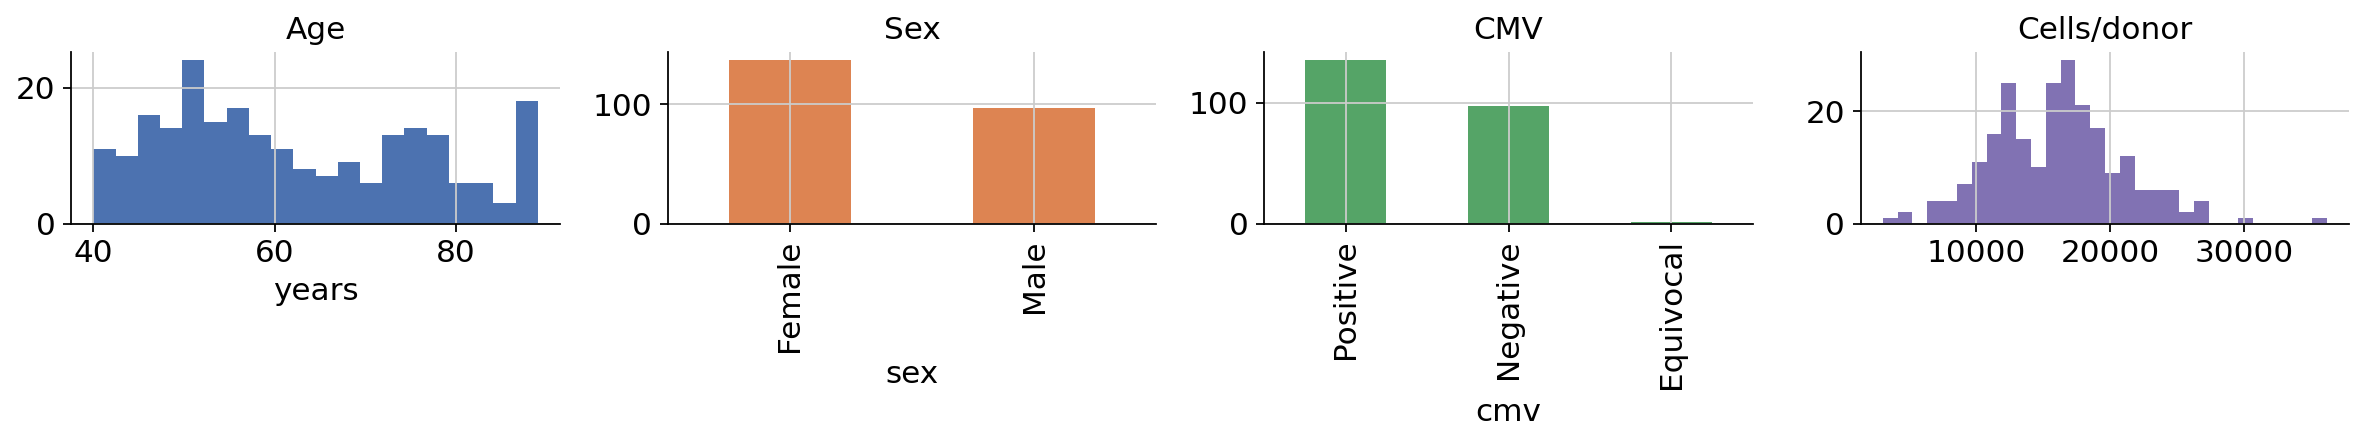

In [4]:
# Build a donor-level metadata table; we re-use it for every method below.
def donor_meta_from(adata, age_col="age", sample_col="donor",
                    keep=("subject.biologicalSex","subject.cmv","subject.race",
                          "batch_id","pool_id","chip_id","AIFI_L2")):
    cols = [sample_col, age_col, "age_group"] + [c for c in keep if c in adata.obs.columns]
    df = adata.obs[cols].copy()
    return df.groupby(sample_col, observed=True).agg(
        age=("age","first"), age_group=("age_group","first"),
        sex=("subject.biologicalSex","first"),
        cmv=("subject.cmv","first"),
        race=("subject.race","first"),
        batch=("batch_id","first"),
        pool=("pool_id","first"),
        chip=("chip_id","first"),
        n_cells=("AIFI_L2","size"),
    )

donor_meta = donor_meta_from(adata)
print(donor_meta.head())

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].hist(donor_meta.age, bins=20, color="#4C72B0"); axes[0].set_title("Age"); axes[0].set_xlabel("years")
donor_meta.sex.value_counts().plot(kind="bar", ax=axes[1], color="#DD8452"); axes[1].set_title("Sex")
donor_meta.cmv.value_counts().plot(kind="bar", ax=axes[2], color="#55A467"); axes[2].set_title("CMV")
donor_meta.n_cells.plot(kind="hist", bins=30, ax=axes[3], color="#8172B3"); axes[3].set_title("Cells/donor")
for ax in axes: ax.set_ylabel("")
plt.tight_layout(); plt.show()

### Pre-existing biology: composition shifts with age

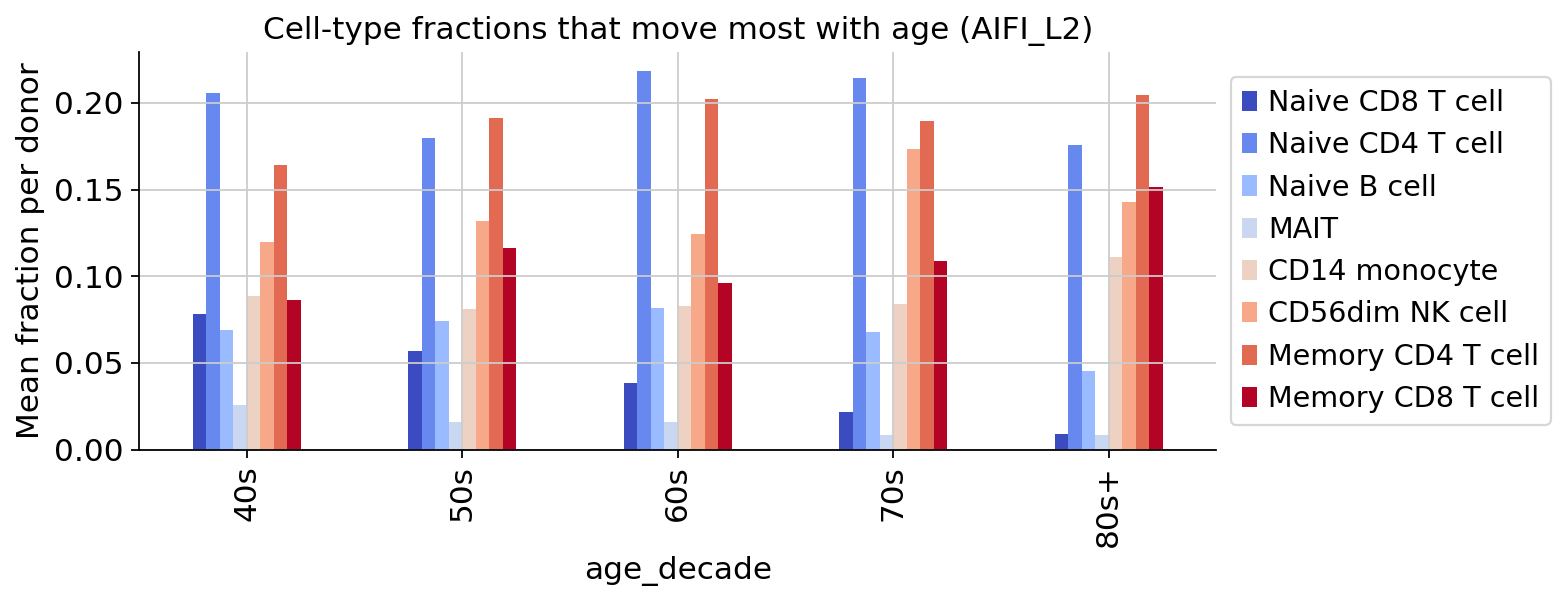

In [5]:
# Per-donor AIFI_L2 fractions, then mean by age decade.
obs_donor = adata.obs["donor"].astype(str)
ct = pd.crosstab(obs_donor, adata.obs["AIFI_L2"].astype(str), normalize="index")
donor_meta["age_decade"] = pd.cut(donor_meta.age, bins=[39,50,60,70,80,90],
                                  labels=["40s","50s","60s","70s","80s+"], right=False)
ct_dec = ct.join(donor_meta["age_decade"]).groupby("age_decade", observed=True).mean()
delta = (ct_dec.iloc[-1] - ct_dec.iloc[0]).sort_values()
top_movers = list(delta.head(4).index) + list(delta.tail(4).index)
ct_dec.loc[:, top_movers].plot(kind="bar", colormap="coolwarm", figsize=(10, 4))
plt.ylabel("Mean fraction per donor"); plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Cell-type fractions that move most with age (AIFI_L2)")
plt.tight_layout(); plt.show()

## Shared utilities

Most of the work is the same for every method: filter small donors, pick
a train/test donor split, fit the method, compute a held-out K-NN
regression of age, score the technical / biological covariates. We
define the helpers once.

In [6]:
def filter_and_subsample(adata, sample_size_threshold=200, max_cells_per_donor=None, seed=SEED):
    """Drop donors below ``sample_size_threshold`` cells; optionally subsample."""
    a = patpy.pp.filter_small_samples(adata, sample_key="donor", sample_size_threshold=sample_size_threshold)
    if max_cells_per_donor is None:
        return a
    rng = np.random.default_rng(seed)
    obs_idx = np.arange(a.n_obs)
    keep = []
    grouped = pd.Series(a.obs["donor"].values).groupby(a.obs["donor"].values, observed=True).indices
    for _donor, idx in grouped.items():
        if len(idx) <= max_cells_per_donor:
            keep.append(obs_idx[idx])
        else:
            keep.append(obs_idx[rng.choice(idx, size=max_cells_per_donor, replace=False)])
    return a[np.sort(np.concatenate(keep))].copy()

def smoke_subset(adata, n_donors=20, max_cells_per_donor=200, seed=SEED):
    rng = np.random.default_rng(seed)
    donors = pd.unique(adata.obs["donor"].astype(str))
    donors = donors[rng.permutation(len(donors))[:n_donors]]
    sub = adata[adata.obs["donor"].astype(str).isin(donors)].copy()
    return filter_and_subsample(sub, sample_size_threshold=0, max_cells_per_donor=max_cells_per_donor)

if SMOKE:
    # adata was loaded with smoke=True above, already restricted to ~20 donors.
    # Now cap cells per donor.
    adata = filter_and_subsample(adata, sample_size_threshold=0,
                                  max_cells_per_donor=N_CELLS_PER_DONOR)
    donor_meta = donor_meta_from(adata)
    print(f"smoke subset: n_cells={adata.n_obs:,}  n_donors={adata.obs['donor'].nunique()}")

In [7]:
def donor_train_test_split(donors, seed=SEED, test_fraction=TEST_FRACTION):
    rng = np.random.default_rng(seed)
    donors = np.asarray(donors)
    perm = rng.permutation(len(donors))
    n_test = max(1, int(round(len(donors) * test_fraction)))
    test_set = set(donors[perm[:n_test]].tolist())
    train = [d for d in donors if d not in test_set]
    test = [d for d in donors if d in test_set]
    return train, test

def score_age_held_out(distances, age_per_donor, train_donors, test_donors, donor_order,
                       n_neighbors=N_NEIGHBORS):
    """Predict held-out donors' ages by KNN on the distance matrix."""
    idx = {d: i for i, d in enumerate(donor_order)}
    train_i = np.array([idx[d] for d in train_donors if d in idx])
    test_i  = np.array([idx[d] for d in test_donors  if d in idx])
    if len(test_i) == 0:
        return {"r2": np.nan, "spearman": np.nan, "mae": np.nan, "n_test": 0}
    age = pd.Series(age_per_donor).reindex(donor_order).values.astype(float)
    train_i = train_i[~np.isnan(age[train_i])]
    test_i  = test_i [~np.isnan(age[test_i])]
    if len(train_i) == 0 or len(test_i) == 0:
        return {"r2": np.nan, "spearman": np.nan, "mae": np.nan, "n_test": int(len(test_i))}
    D = distances[np.ix_(test_i, train_i)]
    k = min(n_neighbors, len(train_i))
    nn = np.argsort(D, axis=1)[:, :k]
    y_pred = age[train_i][nn].mean(axis=1)
    y_true = age[test_i]
    rho, _ = spearmanr(y_true, y_pred)
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "spearman": float(rho) if not np.isnan(rho) else np.nan,
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "n_test": int(len(test_i)),
    }

donor_order = list(pd.unique(adata.obs["donor"].astype(str)))
train_donors, test_donors = donor_train_test_split(donor_order, seed=SEED)
print(f"split: train={len(train_donors)} test={len(test_donors)}")

split: train=187 test=47


## Method 1 — Pseudobulk

Mean of the cell-level `X_pca` embedding within each donor, Euclidean
distance between those means. Cheap, interpretable, ignores
within-donor heterogeneity.

In [8]:
def fit_pseudobulk(adata):
    pb = patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="AIFI_L2",
                              layer="X_pca", seed=SEED)
    pb.prepare_anndata(adata)
    dist = pb.calculate_distance_matrix()
    emb = pd.DataFrame(pb.sample_representation, index=pb.samples)
    return emb, dist

t0 = time.time()
emb_pb, dist_pb = fit_pseudobulk(adata)
score_pb = score_age_held_out(dist_pb, donor_meta["age"], train_donors, test_donors, emb_pb.index.astype(str).tolist())
print(f"pseudobulk: {time.time()-t0:.1f}s  R²={score_pb['r2']:.3f}  Spearman={score_pb['spearman']:.3f}  MAE={score_pb['mae']:.2f}")

pseudobulk: 12.3s  R²=0.149  Spearman=0.429  MAE=9.93


## Method 2 — Cell-group composition (CLR)

In [9]:
def fit_composition(adata):
    comp = patpy.tl.CellGroupComposition(sample_key="donor",
                                          cell_group_key="AIFI_L2",
                                          apply_clr=True, seed=SEED)
    comp.prepare_anndata(adata)
    dist = comp.calculate_distance_matrix()
    rep = comp.sample_representation
    emb = rep if isinstance(rep, pd.DataFrame) else pd.DataFrame(rep, index=comp.samples)
    return emb, dist

t0 = time.time()
emb_comp, dist_comp = fit_composition(adata)
score_comp = score_age_held_out(dist_comp, donor_meta["age"], train_donors, test_donors, emb_comp.index.astype(str).tolist())
print(f"composition (CLR): {time.time()-t0:.1f}s  R²={score_comp['r2']:.3f}  Spearman={score_comp['spearman']:.3f}  MAE={score_comp['mae']:.2f}")

composition (CLR): 0.7s  R²=0.302  Spearman=0.515  MAE=8.34


## Method 3 — GloScope (Python)

In [10]:
def fit_gloscope(adata):
    # GloScope_py needs an embedding-style layer; subsample per donor (slow at full size).
    sub = filter_and_subsample(adata, sample_size_threshold=0,
                                max_cells_per_donor=N_CELLS_PER_DONOR)
    gs = patpy.tl.GloScope_py(sample_key="donor", cell_group_key="AIFI_L2",
                              layer="X_pca", k=25, seed=SEED)
    gs.prepare_anndata(sub)
    dist = gs.calculate_distance_matrix()
    # Project to a small embedding via classical MDS for downstream KNN.
    d = dist.values if isinstance(dist, pd.DataFrame) else np.asarray(dist)
    n = d.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (d.astype(np.float64) ** 2) @ H
    w, v = np.linalg.eigh(B); order = np.argsort(-w)[:16]
    coords = v[:, order] * np.sqrt(np.clip(w[order], 0, None))
    samples = list(dist.index) if isinstance(dist, pd.DataFrame) else list(gs.samples)
    return pd.DataFrame(coords, index=samples), d.astype(np.float32)

t0 = time.time()
emb_gs, dist_gs = fit_gloscope(adata)
score_gs = score_age_held_out(dist_gs, donor_meta["age"], train_donors, test_donors, emb_gs.index.astype(str).tolist())
print(f"GloScope_py: {time.time()-t0:.1f}s  R²={score_gs['r2']:.3f}  Spearman={score_gs['spearman']:.3f}  MAE={score_gs['mae']:.2f}")

0 samples removed: 


GloScope_py: 520.9s  R²=0.166  Spearman=0.427  MAE=10.06


## Method 4 — SampleCLR (SSL + FT)

SampleCLR trains a contrastive aggregator over cell embeddings; we
snapshot it at the **SSL** stage (after self-supervised pretrain, no
labels) and after **fine-tuning** on age. We also pull per-cell
attention weights for the deeper analysis below.

The `use_batch_aware_sampler` flag tells the contrastive loss to balance
sequencing batches when forming positive/negative pairs — useful when
the technical batches are confounded with biology.

In [11]:
def fit_sampleclr(adata):
    from sampleclr import ContrastiveModel
    from sampleclr.utils import get_sample_representations_from_adata

    sub = filter_and_subsample(adata, sample_size_threshold=0,
                                max_cells_per_donor=N_CELLS_PER_DONOR)
    sample_order = list(pd.unique(sub.obs["donor"].astype(str)))
    n_epochs = 10 if SMOKE else 40
    model = ContrastiveModel(
        adata=sub, sample_key="donor", layer="X_pca",
        tasks={"regression": ["age"]},
        batch_size=8,
        num_epochs_stage1=n_epochs, num_epochs_stage2=n_epochs,
        num_warmup_epochs_stage1=max(1, n_epochs // 5),
        num_warmup_epochs_stage2=max(1, n_epochs // 5),
        early_stopping_patience=3 if SMOKE else 8,
        use_batch_aware_sampler=True,
        batch_sampler_batch_col="batch_id",
        verbose=False,
        seed=SEED,
    )

    # --- snapshot SSL (after pretrain, before fine_tune) ---
    model.pretrain()
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    rep_ssl = get_sample_representations_from_adata(
        projector=model.projector, aggregator=model.aggregator,
        adata=sub, sample_key="donor", layer="X_pca",
        meta_obs_names=sample_order, subset_size=N_CELLS_PER_DONOR, device=dev,
    )
    ssl_emb = pd.DataFrame(np.asarray(rep_ssl), index=sample_order)
    ssl_dist = squareform(pdist(ssl_emb.values, metric="euclidean")).astype(np.float32)

    # --- snapshot FT (after supervised fine-tune) ---
    model.fine_tune(val_metric="loss")
    rep_ft = get_sample_representations_from_adata(
        projector=model.projector, aggregator=model.aggregator,
        adata=sub, sample_key="donor", layer="X_pca",
        meta_obs_names=sample_order, subset_size=N_CELLS_PER_DONOR, device=dev,
    )
    ft_emb = pd.DataFrame(np.asarray(rep_ft), index=sample_order)
    ft_dist = squareform(pdist(ft_emb.values, metric="euclidean")).astype(np.float32)
    return model, sub, ssl_emb, ssl_dist, ft_emb, ft_dist

t0 = time.time()
sclr_model, sclr_adata, emb_ssl, dist_ssl, emb_ft, dist_ft = fit_sampleclr(adata)
score_ssl = score_age_held_out(dist_ssl, donor_meta["age"], train_donors, test_donors, emb_ssl.index.astype(str).tolist())
score_ft  = score_age_held_out(dist_ft,  donor_meta["age"], train_donors, test_donors, emb_ft.index.astype(str).tolist())
print(f"SampleCLR: {time.time()-t0:.1f}s")
print(f"  SSL  R²={score_ssl['r2']:.3f}  Spearman={score_ssl['spearman']:.3f}  MAE={score_ssl['mae']:.2f}")
print(f"  FT   R²={score_ft['r2']:.3f}  Spearman={score_ft['spearman']:.3f}  MAE={score_ft['mae']:.2f}")

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0 samples removed: 


Stage 1: Contrastive-only training (pretrain)


Epoch 1/40 - Loss: 0.0211, Contr: 0.0210, Top1: 1.000, Top5: 1.000 | Time: 20.44s (30 batches, 632.0ms/batch)


Epoch 2/40 - Loss: 0.0141, Contr: 0.0140, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.1ms/batch)


...


Epoch 37/40 | Time: 0.32s (30 batches, 6.9ms/batch)
contrastive – train: 0.0016 – val: N/A
regression (age) – train: 0.2890 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 38/40 | Time: 0.33s (30 batches, 7.0ms/batch)
contrastive – train: 0.0012 – val: N/A
regression (age) – train: 0.3299 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 39/40 | Time: 0.32s (30 batches, 6.9ms/batch)
contrastive – train: 0.0008 – val: N/A
regression (age) – train: 0.3723 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 40/40 | Time: 0.32s (30 batches, 6.9ms/batch)
contrastive – train: 0.0008 – val: N/A
regression (age) – train: 0.3410 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------


SampleCLR: 145.7s
  SSL  R²=0.054  Spearman=0.311  MAE=10.95
  FT   R²=0.848  Spearman=0.908  MAE=3.81


## Method 5 — PaSCient

A cell→patient attention transformer that we train end-to-end on
continuous age. Three guardrails matter for the `X_pca` input:

- `tasks=["regression"]` (the patpy wrapper swaps in MSELoss for us);
- z-scoring of the target so MSE doesn't explode against raw ages —
  done automatically inside the patpy wrapper for regression;
- `normalize=False`: the default takes `log()` of the input layer, and
  `X_pca` has negative values, so the default normalisation NaN-poisons
  the embedding.

PaSCient is GPU-preferred; it falls back to CPU but takes 5-10× longer.

In [12]:
def fit_pascient(adata):
    sub = filter_and_subsample(adata, sample_size_threshold=0,
                                max_cells_per_donor=N_CELLS_PER_DONOR)
    n_per_donor = max(1, sub.n_obs // max(1, sub.obs["donor"].nunique()))
    pa = patpy.tl.PaSCient(
        sample_key="donor", label_keys=["age"], tasks=["regression"],
        cell_group_key="AIFI_L2", layer="X_pca",
        n_cells=min(N_CELLS_PER_DONOR, n_per_donor),
        batch_size=16 if torch.cuda.is_available() else 8,
        n_epochs=2 if SMOKE else 30,
        device="cuda" if torch.cuda.is_available() else "cpu",
        normalize=False,           # X_pca is already an embedding, do NOT log()
        seed=SEED,
    )
    pa.prepare_anndata(sub, train=True)
    rep = pa.get_sample_representations()
    dist = squareform(pdist(rep.values, metric="euclidean")).astype(np.float32)
    return rep, dist

t0 = time.time()
emb_pa, dist_pa = fit_pascient(adata)
score_pa = score_age_held_out(dist_pa, donor_meta["age"], train_donors, test_donors, emb_pa.index.astype(str).tolist())
print(f"PaSCient: {time.time()-t0:.1f}s  R²={score_pa['r2']:.3f}  Spearman={score_pa['spearman']:.3f}  MAE={score_pa['mae']:.2f}")

0 samples removed: 


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


PaSCient: 551.4s  R²=0.592  Spearman=0.759  MAE=5.51


## Method 6 — MixMIL

Mixed model + multiple instance learning. The upstream `mixmil` library
only offers binomial / categorical likelihoods, so we train it on
``age_group = age >= 65`` instead of continuous age. The learned
donor embedding still carries continuous age structure for the K-NN.

In [13]:
def fit_mixmil(adata):
    sub = filter_and_subsample(adata, sample_size_threshold=0,
                                max_cells_per_donor=N_CELLS_PER_DONOR)
    mm = patpy.tl.MixMIL(
        sample_key="donor", label_keys=["age_group"], tasks=["classification"],
        cell_group_key="AIFI_L2", layer="X_pca",
        likelihood="binomial", n_trials=2,
        n_epochs=200 if SMOKE else 1500,
        batch_size=8, seed=SEED,
    )
    mm.prepare_anndata(sub, train=True)
    rep = mm.get_sample_representations()
    dist = squareform(pdist(rep.values, metric="euclidean")).astype(np.float32)
    return rep, dist

t0 = time.time()
emb_mm, dist_mm = fit_mixmil(adata)
score_mm = score_age_held_out(dist_mm, donor_meta["age"], train_donors, test_donors, emb_mm.index.astype(str).tolist())
print(f"MixMIL: {time.time()-t0:.1f}s  R²={score_mm['r2']:.3f}  Spearman={score_mm['spearman']:.3f}  MAE={score_mm['mae']:.2f}")

0 samples removed: 


GLMM Init:   0%|          | 0/1 [00:00<?, ?it/s]

GLMM Init: 100%|██████████| 1/1 [00:00<00:00,  1.87it/s]

GLMM Init: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s]

Epoch:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Epoch: 100%|█████████▉| 1498/1500 [04:56<00:00,  4.95it/s]

Epoch: 100%|█████████▉| 1499/1500 [04:56<00:00,  5.00it/s]

Epoch: 100%|██████████| 1500/1500 [04:56<00:00,  4.87it/s]

Epoch: 100%|██████████| 1500/1500 [04:56<00:00,  5.06it/s]

MixMIL: 340.2s  R²=0.255  Spearman=0.463  MAE=9.56


## Cross-method comparison on the aging cohort

                  r2  spearman     mae  n_test
method                                        
pseudobulk     0.149     0.429   9.928      47
composition    0.302     0.515   8.340      47
gloscope       0.166     0.427  10.064      47
sampleclr-SSL  0.054     0.311  10.953      47
sampleclr-FT   0.848     0.908   3.813      47
pascient       0.592     0.759   5.511      47
mixmil         0.255     0.463   9.557      47


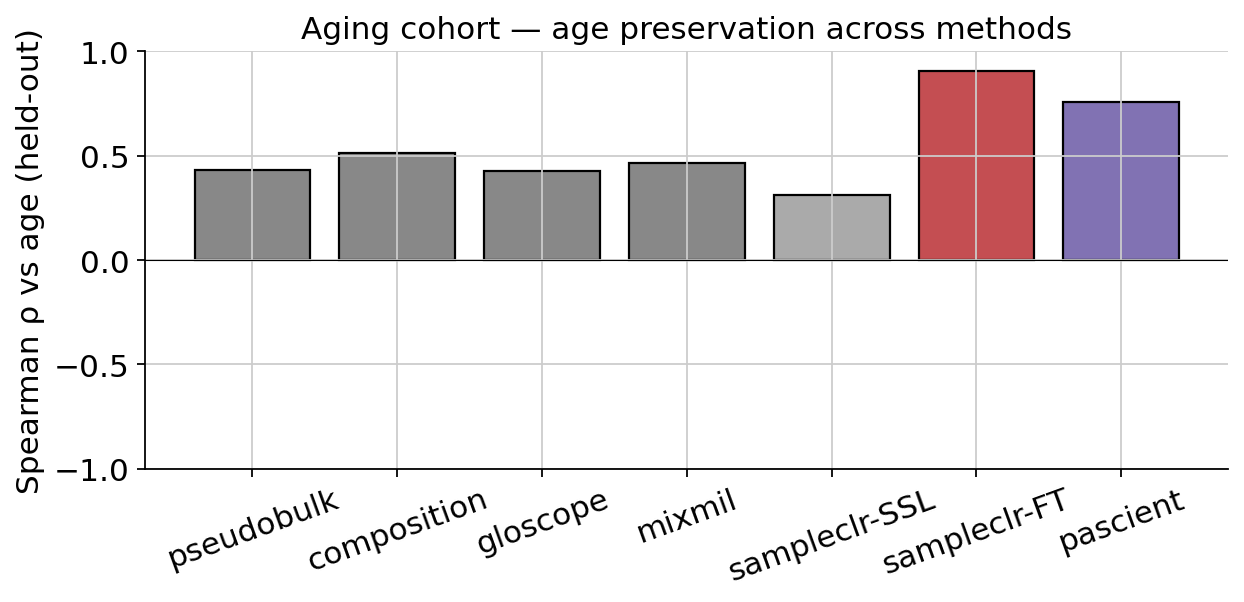

In [14]:
def collect_scores():
    rows = [
        {"method": "pseudobulk",  **score_pb},
        {"method": "composition", **score_comp},
        {"method": "gloscope",    **score_gs},
        {"method": "sampleclr-SSL", **score_ssl},
        {"method": "sampleclr-FT",  **score_ft},
        {"method": "pascient",    **score_pa},
        {"method": "mixmil",      **score_mm},
    ]
    return pd.DataFrame(rows).set_index("method")[["r2", "spearman", "mae", "n_test"]]

aging_scores = collect_scores()
print(aging_scores.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
order = ["pseudobulk", "composition", "gloscope", "mixmil",
         "sampleclr-SSL", "sampleclr-FT", "pascient"]
sub = aging_scores.reindex(order)
colors = ["#888"] * 4 + ["#aaa", "#C44E52", "#8172B3"]
ax.bar(sub.index, sub["spearman"], color=colors, edgecolor="black")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylim(-1, 1)                # Spearman is bounded in [-1, 1]; lock the range
ax.set_ylabel("Spearman ρ vs age (held-out)")
ax.set_title("Aging cohort — age preservation across methods")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## Biology: which cell types correlate with age?

Composition (CLR) ignores expression entirely — yet it reaches the
strongest unsupervised score on this cohort. So most of the
predictable variance must live in the cell-type fractions themselves.
We Pearson-correlate each per-donor cell-type fraction with age.

Top cell types DECREASING with age (AIFI):
                      r    p
Naive CD8 T cell -0.615  0.0
CD8aa            -0.415  0.0
MAIT             -0.344  0.0
ILC              -0.250  0.0
Memory B cell    -0.242  0.0

Top cell types INCREASING with age (AIFI):
                       r      p
Platelet           0.123  0.060
Effector B cell    0.123  0.060
Memory CD4 T cell  0.136  0.037
Memory CD8 T cell  0.162  0.013
CD56dim NK cell    0.175  0.007


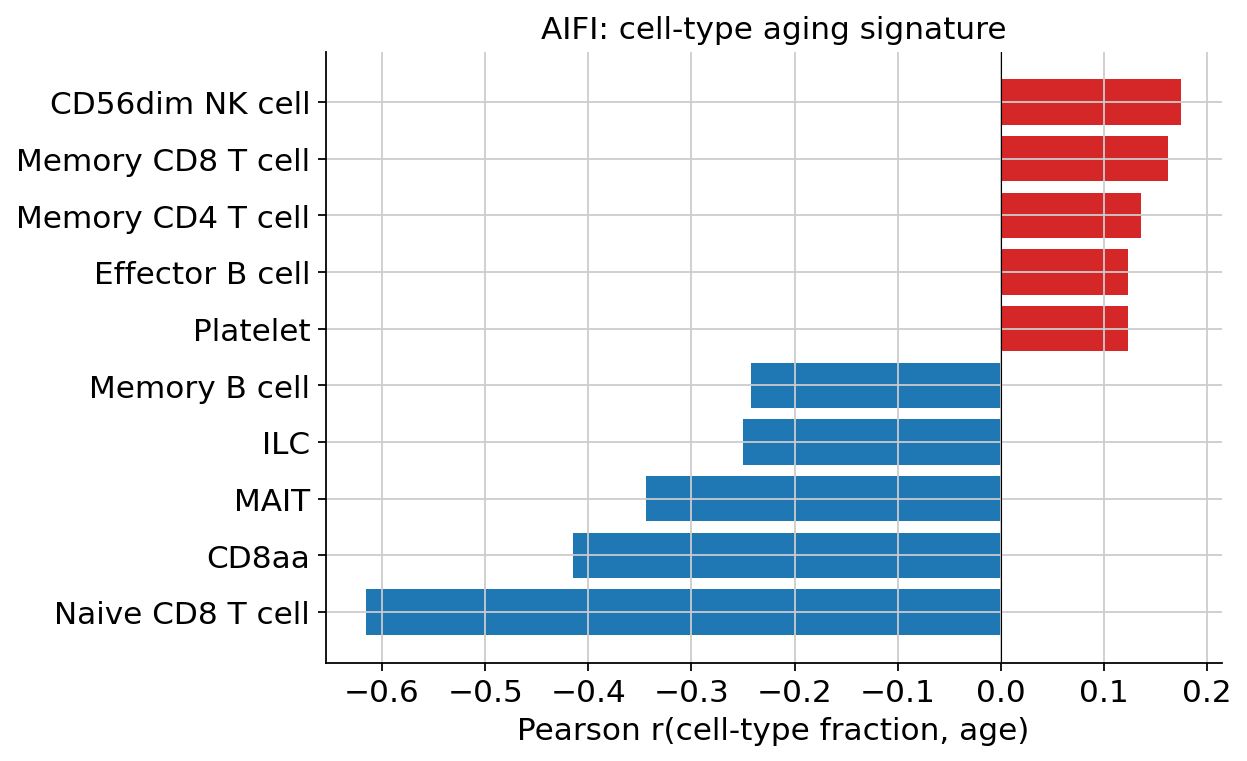

In [15]:
donor_ct = ct.join(donor_meta["age"])
ages = donor_ct.pop("age")
corr_aging = donor_ct.apply(lambda c: pd.Series({
    "r": pearsonr(c, ages)[0],
    "p": pearsonr(c, ages)[1],
})).T.sort_values("r")
print("Top cell types DECREASING with age (AIFI):")
print(corr_aging.head(5).round(3))
print("\nTop cell types INCREASING with age (AIFI):")
print(corr_aging.tail(5).round(3))

fig, ax = plt.subplots(figsize=(8, 5))
top = pd.concat([corr_aging.head(5), corr_aging.tail(5)])
ax.barh(top.index, top["r"], color=["#1f77b4" if r<0 else "#d62728" for r in top["r"]])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(cell-type fraction, age)")
ax.set_title("AIFI: cell-type aging signature"); plt.tight_layout(); plt.show()

### Genes correlated with age (pseudobulk-level)

The pseudobulk method computes a donor-level mean of the per-cell `X_pca`
embedding. To go back to gene resolution we do the same averaging at the
expression level: per donor, take the mean log-normalised expression of
every gene, then Pearson-correlate each gene's vector across donors with
age. These are the genes whose **donor-mean expression shifts with age**,
i.e. the gene-level aging signature that the pseudobulk distance is
implicitly leveraging.

In [16]:
# Pseudobulk gene expression per donor (mean of cells, in log-normalised space).
# We do it in chunks of donors so we never densify the full matrix at once.
def pseudobulk_genes(adata, sample_key="donor"):
    donors = list(pd.unique(adata.obs[sample_key].astype(str)))
    gene_names = adata.var_names.astype(str).tolist()
    out = np.zeros((len(donors), adata.n_vars), dtype=np.float32)
    obs = adata.obs[sample_key].astype(str).values
    for i, d in enumerate(donors):
        mask = obs == d
        Xd = adata.X[mask]
        if hasattr(Xd, "toarray"):
            Xd = Xd.toarray()
        out[i] = np.asarray(Xd, dtype=np.float32).mean(axis=0)
    return pd.DataFrame(out, index=donors, columns=gene_names)

bulk_aging = pseudobulk_genes(adata)
print(f"pseudobulk matrix: {bulk_aging.shape}  (donors x genes)")

age_aifi = donor_meta["age"].reindex(bulk_aging.index).astype(float).values
mask = np.isfinite(age_aifi)
Xb = bulk_aging.values[mask]
ya = age_aifi[mask]
mu = Xb.mean(axis=0); sd = Xb.std(axis=0) + 1e-12
yc = ya - ya.mean(); ys = ya.std() + 1e-12
gene_r = ((Xb - mu) / sd).T @ (yc / ys) / len(yc)
gene_corr = pd.Series(gene_r, index=bulk_aging.columns, name="r").sort_values()
print("\nTop 10 genes DECREASING with age in AIFI pseudobulk:")
print(gene_corr.head(10).round(3))
print("\nTop 10 genes INCREASING with age:")
print(gene_corr.tail(10).round(3))

pseudobulk matrix: (234, 4000)  (donors x genes)

Top 10 genes DECREASING with age in AIFI pseudobulk:
ROBO1    -0.606
CD248    -0.565
SFRP5    -0.538
FLNB     -0.506
NT5E     -0.500
LRRN3    -0.482
NRCAM    -0.469
SHANK1   -0.461
MXRA8    -0.414
IGFBP6   -0.404
Name: r, dtype: float64

Top 10 genes INCREASING with age:
CPQ        0.376
RNF149     0.377
KATNAL1    0.392
EDA        0.393
GREM2      0.401
FNDC3B     0.401
UPP1       0.402
PRDM1      0.449
ADGRE5     0.465
INPP4B     0.477
Name: r, dtype: float64


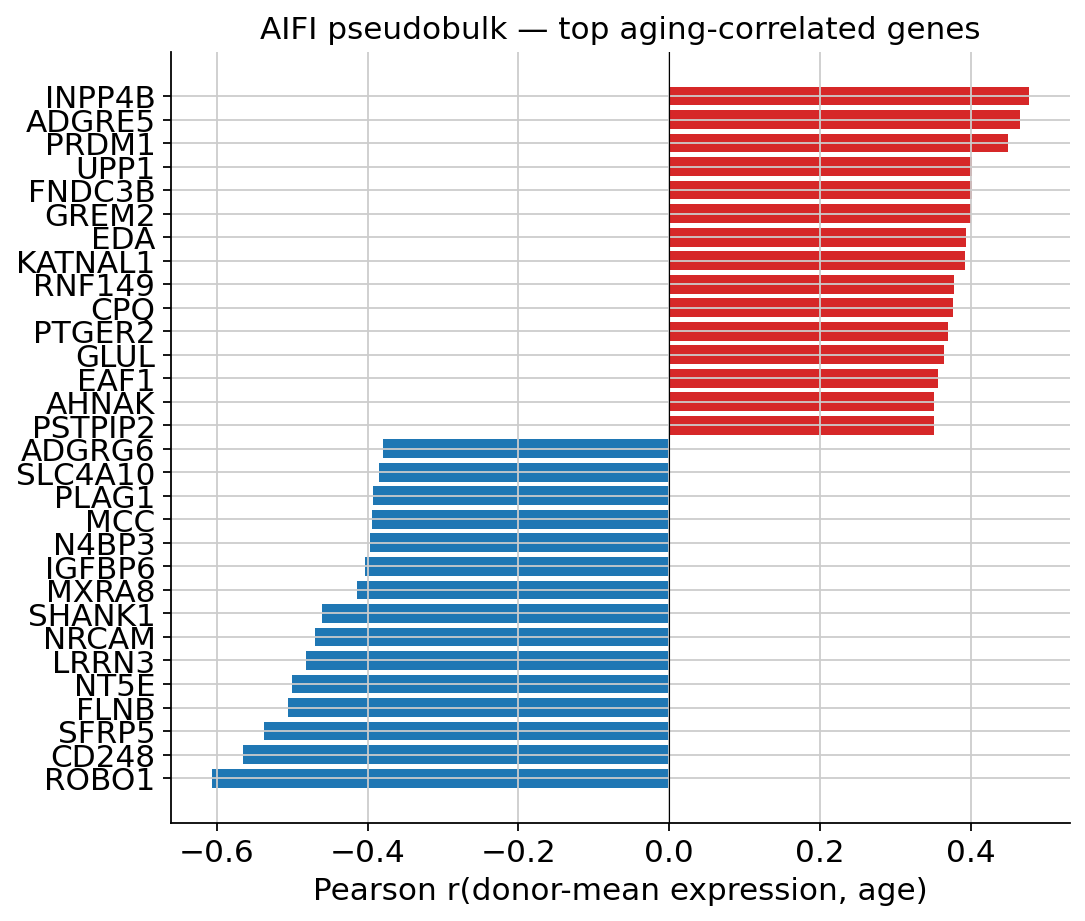

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
top = pd.concat([gene_corr.head(15), gene_corr.tail(15)]).sort_values()
ax.barh(top.index, top.values, color=["#1f77b4" if r<0 else "#d62728" for r in top.values])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(donor-mean expression, age)")
ax.set_title("AIFI pseudobulk — top aging-correlated genes")
plt.tight_layout(); plt.show()

### Connecting the PCs back to genes

The pseudobulk distance lives in 50-D `X_pca` space; the methods above
treat each PC as a feature without knowing what biology lives in it. We
can read each PC's "meaning" off its loadings (`adata.varm["PCs"]` — the
eigenvectors that mapped log-normalised gene expression into the 50-D PCA
space).

For each donor-level age-correlated PC, the top-loading genes tell us
what transcriptional program drove that PC.

In [18]:
# Per-donor mean of X_pca = the pseudobulk vector. Correlate each PC with age.
pca_per_donor = pd.DataFrame(
    np.asarray([adata[adata.obs["donor"].astype(str) == d].obsm["X_pca"].mean(axis=0)
                for d in pd.unique(adata.obs["donor"].astype(str))]),
    index=pd.unique(adata.obs["donor"].astype(str)),
    columns=[f"PC{i+1}" for i in range(adata.obsm["X_pca"].shape[1])],
)
age = donor_meta["age"].reindex(pca_per_donor.index).astype(float).values
pc_r = pd.Series(
    [pearsonr(pca_per_donor[c].values, age)[0] for c in pca_per_donor.columns],
    index=pca_per_donor.columns, name="r"
).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top 10 PCs by |r(donor-mean PC, age)|:")
print(pc_r.head(10).round(3))

Top 10 PCs by |r(donor-mean PC, age)|:
PC9     0.391
PC28    0.352
PC8    -0.288
PC10   -0.277
PC22   -0.249
PC26   -0.247
PC27   -0.212
PC25   -0.212
PC21    0.206
PC43    0.206
Name: r, dtype: float64


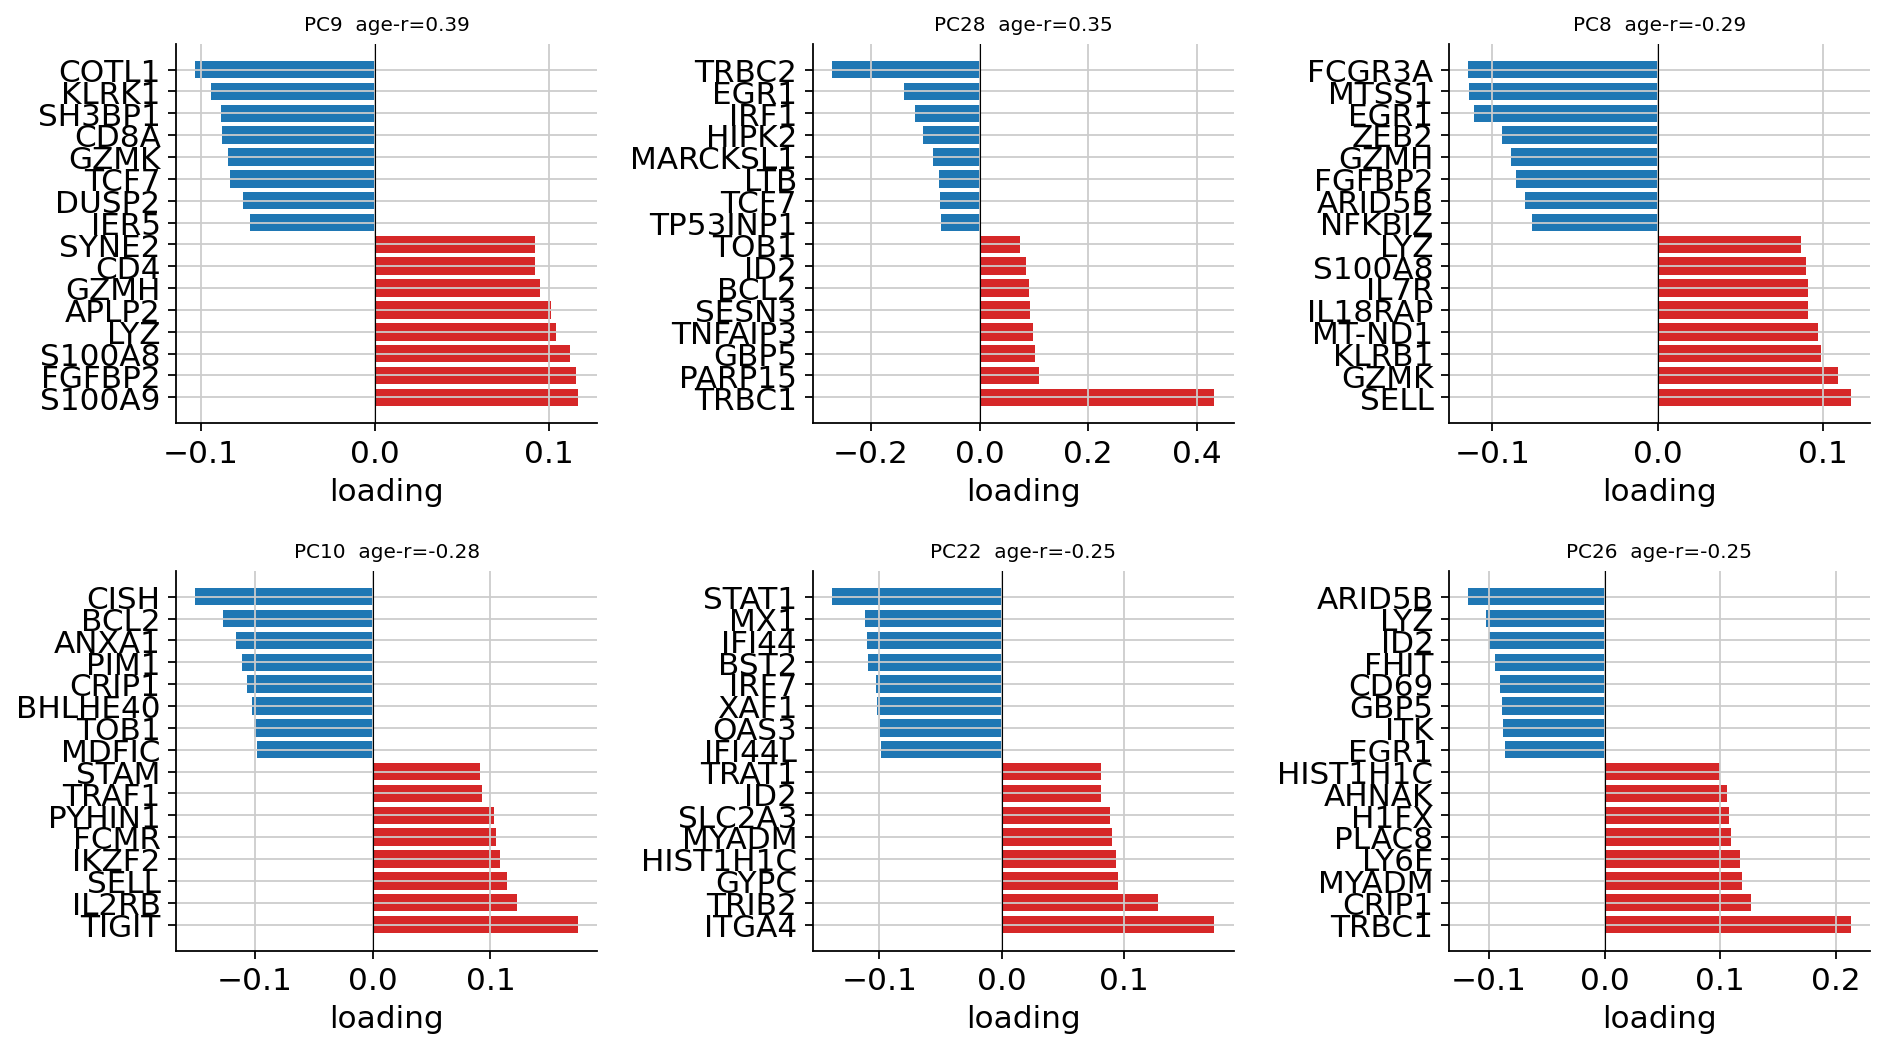

In [19]:
# Get loadings (varm["PCs"]) and read top-loading genes for the top-r PCs.
loadings = pd.DataFrame(adata.varm["PCs"],
                         index=adata.var_names.astype(str),
                         columns=[f"PC{i+1}" for i in range(adata.varm["PCs"].shape[1])])

top_pcs = pc_r.head(6).index.tolist()
ncols = 3; nrows = int(np.ceil(len(top_pcs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.4), squeeze=False)
for ax, pc in zip(axes.ravel(), top_pcs):
    loads = loadings[pc].sort_values()
    top_g = pd.concat([loads.head(8), loads.tail(8)])
    colors = ["#1f77b4" if v<0 else "#d62728" for v in top_g.values]
    ax.barh(top_g.index, top_g.values, color=colors)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{pc}  age-r={pc_r[pc]:.2f}", fontsize=9)
    ax.set_xlabel("loading")
    ax.invert_yaxis()
for ax in axes.ravel()[len(top_pcs):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

**Reading the loading plots.** For each of the top age-correlated PCs,
red bars are genes that **load positively** on the PC (cells expressing
them shift the PC value up) and blue bars are genes loading negatively.
Combined with the header's `age-r`:

- A PC with `age-r > 0` whose red bars include cytotoxic markers
  (`GZMB`, `GNLY`, `PRF1`, `NKG7`) tells us: *donors with more cells
  expressing this cytotoxic program score higher on this PC, and that
  PC tracks age*.
- A PC with `age-r < 0` whose red bars include naive T markers
  (`CCR7`, `LEF1`, `TCF7`, `SELL`) tells us the *opposite* — that PC
  encodes naivety, and naivety drops with age.

This is the same biology you'd get from a manual differential test on
pseudobulks, just routed through the PCA the methods actually consume.

## Cross-cohort validation on OneK1K

Same three unsupervised methods + SampleCLR on a 981-donor independent
cohort with age 19–97. If a method captures *aging* and not *AIFI
quirks*, the score on OneK1K should look similar.

In [20]:
def load_onek1k():
    a, _ = patpy.datasets.onek1k(return_dataset_info=True)
    a.obs["donor"] = a.obs["donor_id"].astype(str)
    a.obs["age_group"] = np.where(a.obs["age"] >= 65, "old", "young")
    return a

t0 = time.time()
adata_one = load_onek1k()
if SMOKE:
    adata_one = smoke_subset(adata_one, n_donors=20, max_cells_per_donor=N_CELLS_PER_DONOR)
print(f"OneK1K: n_cells={adata_one.n_obs:,}  n_donors={adata_one.obs['donor'].nunique()}  loaded in {time.time()-t0:.1f}s")

OneK1K: n_cells=1,248,980  n_donors=981  loaded in 12.7s


In [21]:
# Cross-cohort: just the cheap methods to confirm replication.
def fit_pseudobulk_one(a):
    pb = patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="cell_type", layer="X_pca", seed=SEED)
    pb.prepare_anndata(a); d = pb.calculate_distance_matrix()
    return pd.DataFrame(pb.sample_representation, index=pb.samples), d

def fit_composition_one(a):
    comp = patpy.tl.CellGroupComposition(sample_key="donor", cell_group_key="cell_type",
                                          apply_clr=True, seed=SEED)
    comp.prepare_anndata(a); d = comp.calculate_distance_matrix()
    rep = comp.sample_representation
    emb = rep if isinstance(rep, pd.DataFrame) else pd.DataFrame(rep, index=comp.samples)
    return emb, d

donor_meta_one = adata_one.obs[["donor","age","age_group","sex","pool_number"]].copy()
donor_meta_one["donor"] = donor_meta_one["donor"].astype(str)
donor_meta_one = donor_meta_one.groupby("donor", observed=True).agg(
    age=("age","first"), age_group=("age_group","first"),
    sex=("sex","first"), pool=("pool_number","first"),
)

donor_order_one = list(pd.unique(adata_one.obs["donor"].astype(str)))
train_one, test_one = donor_train_test_split(donor_order_one, seed=SEED)

emb_pb_one, dist_pb_one = fit_pseudobulk_one(adata_one)
emb_comp_one, dist_comp_one = fit_composition_one(adata_one)
score_pb_one  = score_age_held_out(dist_pb_one,  donor_meta_one["age"], train_one, test_one, emb_pb_one.index.astype(str).tolist())
score_comp_one = score_age_held_out(dist_comp_one, donor_meta_one["age"], train_one, test_one, emb_comp_one.index.astype(str).tolist())
print(f"OneK1K pseudobulk  R²={score_pb_one['r2']:.3f}  Spearman={score_pb_one['spearman']:.3f}")
print(f"OneK1K composition R²={score_comp_one['r2']:.3f}  Spearman={score_comp_one['spearman']:.3f}")

OneK1K pseudobulk  R²=0.096  Spearman=0.381
OneK1K composition R²=0.301  Spearman=0.526


In [22]:
ct_one = pd.crosstab(adata_one.obs["donor"].astype(str), adata_one.obs["cell_type"].astype(str), normalize="index")
ct_one = ct_one.join(donor_meta_one["age"])
ages_one = ct_one.pop("age")
corr_one = ct_one.apply(lambda c: pd.Series({
    "r": pearsonr(c, ages_one)[0], "p": pearsonr(c, ages_one)[1],
})).T.sort_values("r")
print("OneK1K — top cell types decreasing with age:")
print(corr_one.head(5).round(3))
print("\nTop cell types increasing with age:")
print(corr_one.tail(5).round(3))

OneK1K — top cell types decreasing with age:
                                                        r    p
naive thymus-derived CD8-positive, alpha-beta T... -0.680  0.0
mucosal invariant T cell                           -0.297  0.0
naive thymus-derived CD4-positive, alpha-beta T... -0.200  0.0
memory B cell                                      -0.153  0.0
central memory CD8-positive, alpha-beta T cell     -0.135  0.0

Top cell types increasing with age:
                                                     r      p
central memory CD4-positive, alpha-beta T cell   0.068  0.032
CD4-positive, alpha-beta cytotoxic T cell        0.156  0.000
CD14-low, CD16-positive monocyte                 0.188  0.000
effector memory CD8-positive, alpha-beta T cell  0.218  0.000
natural killer cell                              0.308  0.000


                 AIFI  OneK1K
f                            
B_memory       -0.242  -0.153
B_naive        -0.156  -0.026
CD4_naive      -0.012  -0.200
CD8_naive      -0.615  -0.680
DC             -0.088   0.005
Mono_CD16       0.060   0.188
Mono_classical  0.085   0.056
T_effector      0.123   0.056
plasma         -0.058  -0.111


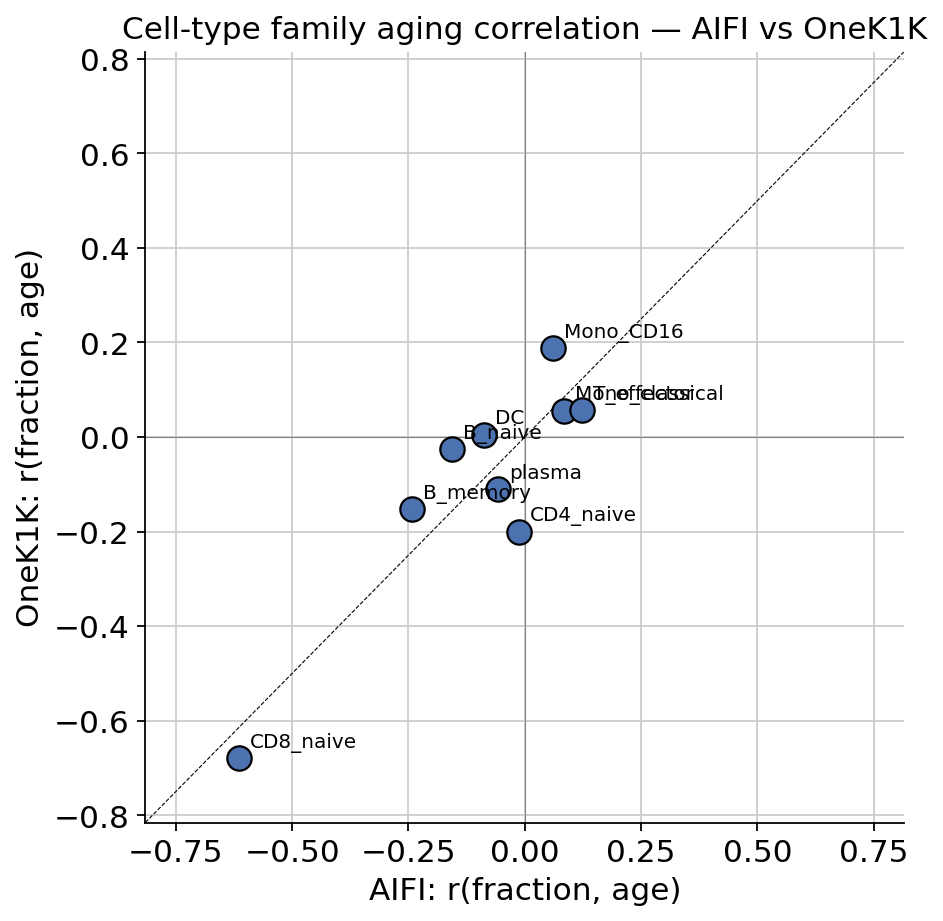

In [23]:
# Cross-cohort cell-type family agreement
def family(name):
    n = str(name).lower()
    if "naive" in n and ("cd4" in n or "t4" in n): return "CD4_naive"
    if "naive" in n and ("cd8" in n or "t8" in n): return "CD8_naive"
    if "tem" in n or "effector" in n or "gzmb" in n: return "T_effector"
    if "treg" in n: return "Treg"
    if "naive b" in n or "b_naive" in n: return "B_naive"
    if "memory b" in n or "b mem" in n: return "B_memory"
    if "monocyte" in n and ("cd16" in n or "non-classical" in n): return "Mono_CD16"
    if "monocyte" in n: return "Mono_classical"
    if "nk" in n: return "NK"
    if "mait" in n or "gdt" in n: return "MAIT_gdT"
    if "dc" in n or "dendritic" in n: return "DC"
    if "plasma" in n: return "plasma"
    return None

aifi_fam = corr_aging.assign(f=corr_aging.index.map(family)).dropna(subset=["f"]).groupby("f")["r"].mean()
one_fam  = corr_one.assign(f=corr_one.index.map(family)).dropna(subset=["f"]).groupby("f")["r"].mean()
both = pd.concat([aifi_fam.rename("AIFI"), one_fam.rename("OneK1K")], axis=1).dropna()
print(both.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both["AIFI"], both["OneK1K"], s=120, c="#4C72B0", edgecolor="black", zorder=3)
for f, r in both.iterrows():
    ax.annotate(f, (r["AIFI"], r["OneK1K"]), xytext=(5, 5),
                textcoords="offset points", fontsize=9)
lim = max(both.abs().max()) * 1.2
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("AIFI: r(fraction, age)"); ax.set_ylabel("OneK1K: r(fraction, age)")
ax.set_title("Cell-type family aging correlation — AIFI vs OneK1K")
plt.tight_layout(); plt.show()

## Generalisation: train on AIFI, predict on OneK1K

So far we re-trained each model from scratch on each cohort. Real
deployment looks more like *train once on a reference cohort, predict
on every new donor that comes in*. Two engineering choices and one
biological question.

**Engineering**

1. **Feature alignment.** AIFI and OneK1K have different gene panels
   and were PCA'd independently, so their `X_pca` spaces are
   incomparable out of the box. We refit a PCA on AIFI restricted to
   the **shared gene panel** (AIFI uses gene symbols, OneK1K uses
   Ensembl IDs with the symbol stored in ``var["feature_name"]``),
   then project OneK1K through those same loadings. Both cohorts now
   live in the same 50-PC space.
2. **Bag size.** AIFI donors have ~16K cells each, OneK1K donors have
   ~1.3K. We use a small bag of 200 cells/donor for both training and
   inference so OneK1K donors aren't dominated by zero-padding.

**Biological question.** Three protocols on the same models:

- **Zero-shot transfer** — train on AIFI, predict OneK1K with no
  further training. Worst case.
- **Fine-tuning with a small donor budget** — train on AIFI, then
  continue training on **10% of OneK1K donors** (with a smaller lr and
  fewer epochs), then predict the remaining 90%. Does a tiny budget
  of in-domain donors fix the transfer gap?
- AIFI in-sample for reference.

The 10% is donor-stratified random; the 90% test set never sees the
fine-tune step.

In [24]:
from sklearn.decomposition import PCA as _SkPCA

def build_shared_pca(aifi, onek1k, n_pcs=50, fit_subsample=300_000, seed=SEED):
    """Recompute PCA on AIFI restricted to shared genes; project both cohorts.

    AIFI stores gene symbols in var_names; OneK1K stores Ensembl IDs in
    var_names with the symbol in var["feature_name"]. We match on symbol.
    """
    aifi_symbols = aifi.var_names.astype(str)
    one_symbols = (onek1k.var["feature_name"].astype(str)
                   if "feature_name" in onek1k.var.columns
                   else onek1k.var_names.astype(str))
    shared = sorted(set(aifi_symbols) & set(one_symbols))
    if len(shared) < 200:
        raise RuntimeError(f"too few shared gene symbols: {len(shared)}")
    print(f"shared gene symbols: {len(shared)}")
    aifi_idx = aifi.var_names.get_indexer(shared)
    one_pos_by_symbol = pd.Series(np.arange(onek1k.n_vars), index=one_symbols.values)
    onek1k_idx = one_pos_by_symbol.reindex(shared).values.astype(int)

    Xa = aifi.X[:, aifi_idx]
    if hasattr(Xa, "toarray"): Xa = Xa.toarray()
    Xa = np.asarray(Xa, dtype=np.float32)
    fit_X = Xa
    if Xa.shape[0] > fit_subsample:
        rng = np.random.default_rng(seed)
        fit_X = Xa[rng.choice(Xa.shape[0], fit_subsample, replace=False)]
    pca = _SkPCA(n_components=n_pcs, svd_solver="randomized", random_state=seed)
    pca.fit(fit_X)
    print(f"PCA fit: cumulative variance = {pca.explained_variance_ratio_.sum():.3f}")
    aifi.obsm["X_pca_shared"] = pca.transform(Xa).astype(np.float32)
    Xo = onek1k.X[:, onek1k_idx]
    if hasattr(Xo, "toarray"): Xo = Xo.toarray()
    Xo = np.asarray(Xo, dtype=np.float32)
    onek1k.obsm["X_pca_shared"] = pca.transform(Xo).astype(np.float32)
    return pca, shared

pca_shared, shared_genes = build_shared_pca(adata, adata_one, n_pcs=50)
print(f"AIFI X_pca_shared: {adata.obsm['X_pca_shared'].shape}")
print(f"OneK1K X_pca_shared: {adata_one.obsm['X_pca_shared'].shape}")

shared gene symbols: 885


PCA fit: cumulative variance = 0.624


AIFI X_pca_shared: (3758514, 50)
OneK1K X_pca_shared: (1248980, 50)


In [25]:
# Bag size used for training + inference. 200 cells fits OneK1K donors well.
N_CELLS_TRANSFER = 50 if SMOKE else 200
FINETUNE_FRACTION = 0.10        # 10% of OneK1K donors used to fine-tune the AIFI model

aifi_t = filter_and_subsample(adata, sample_size_threshold=0,
                                max_cells_per_donor=N_CELLS_TRANSFER)
one_t = filter_and_subsample(adata_one, sample_size_threshold=0,
                              max_cells_per_donor=N_CELLS_TRANSFER)

# Donor-level 10% / 90% split for the OneK1K transfer experiment
one_donors_all = list(pd.unique(one_t.obs["donor"]))
rng_split = np.random.default_rng(SEED)
perm = rng_split.permutation(len(one_donors_all))
n_ft = max(2, int(round(len(one_donors_all) * FINETUNE_FRACTION)))
ft_set = set(np.asarray(one_donors_all)[perm[:n_ft]].tolist())
one_ft = one_t[one_t.obs["donor"].isin(ft_set)].copy()
one_test = one_t[~one_t.obs["donor"].isin(ft_set)].copy()
print(f"AIFI training set:        {aifi_t.n_obs:,} cells  ({aifi_t.obs['donor'].nunique()} donors)")
print(f"OneK1K fine-tune set:     {one_ft.n_obs:,} cells  ({one_ft.obs['donor'].nunique()} donors)")
print(f"OneK1K held-out test set: {one_test.n_obs:,} cells  ({one_test.obs['donor'].nunique()} donors)")

0 samples removed: 


0 samples removed: 


AIFI training set:        46,800 cells  (234 donors)
OneK1K fine-tune set:     19,600 cells  (98 donors)
OneK1K held-out test set: 176,600 cells  (883 donors)


In [26]:
# --- PaSCient transfer with optional fine-tune step ---
pa = patpy.tl.PaSCient(
    sample_key="donor", label_keys=["age"], tasks=["regression"],
    cell_group_key=None, layer="X_pca_shared",
    n_cells=N_CELLS_TRANSFER,
    batch_size=16 if torch.cuda.is_available() else 8,
    n_epochs=2 if SMOKE else 30,
    device="cuda" if torch.cuda.is_available() else "cpu",
    normalize=False, seed=SEED,
)
t0 = time.time()
pa.prepare_anndata(aifi_t, train=True)
print(f"PaSCient AIFI train: {time.time()-t0:.1f}s")
aifi_pa_pred = pa.predict("age")

# 1) Zero-shot: predict OneK1K test set with no further training
pa.adata = one_test
pa.samples = pd.unique(one_test.obs["donor"]).tolist()
pa._cell_embeddings = {}
pa._extract_embeddings(one_test)
one_pa_pred_zs = pa.predict("age")

# 2) Fine-tune on the 10% OneK1K subset (lower lr, fewer epochs)
pa.adata = one_ft
pa.samples = pd.unique(one_ft.obs["donor"]).tolist()
pa.labels = pa._extract_metadata(pa.label_keys)   # refresh donor→label map for OneK1K
pa.lr = 1e-5
pa.n_epochs = 5 if SMOKE else 15
t0 = time.time()
pa._train(one_ft, label_key="age", task="regression")
print(f"PaSCient OneK1K fine-tune ({pa.n_epochs} epochs, lr={pa.lr}): {time.time()-t0:.1f}s")

# 3) Predict the held-out OneK1K test set with the fine-tuned model
pa.adata = one_test
pa.samples = pd.unique(one_test.obs["donor"]).tolist()
pa._cell_embeddings = {}
pa._extract_embeddings(one_test)
one_pa_pred_ft = pa.predict("age")

def _score(y_true, y_pred):
    return {"r2": float(r2_score(y_true, y_pred)),
            "spearman": float(spearmanr(y_true, y_pred)[0]),
            "mae": float(mean_absolute_error(y_true, y_pred))}

aifi_pa_score = _score(donor_meta["age"].reindex(aifi_pa_pred.index).astype(float), aifi_pa_pred)
zs_pa_score  = _score(donor_meta_one["age"].reindex(one_pa_pred_zs.index).astype(float), one_pa_pred_zs)
ft_pa_score  = _score(donor_meta_one["age"].reindex(one_pa_pred_ft.index).astype(float), one_pa_pred_ft)

print(f"PaSCient AIFI in-sample:              R²={aifi_pa_score['r2']:.3f}  Spearman={aifi_pa_score['spearman']:.3f}  MAE={aifi_pa_score['mae']:.2f}")
print(f"PaSCient OneK1K test (zero-shot):     R²={zs_pa_score['r2']:.3f}  Spearman={zs_pa_score['spearman']:.3f}  MAE={zs_pa_score['mae']:.2f}")
print(f"PaSCient OneK1K test (after 10% FT):  R²={ft_pa_score['r2']:.3f}  Spearman={ft_pa_score['spearman']:.3f}  MAE={ft_pa_score['mae']:.2f}")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                        ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gene2cell_encoder           │ BasicMLP                │ 52.2 K │ train │     0 │
│ 1 │ cell2patient_aggregation    │ NonLinearAttnAggregator │  1.1 M │ train │     0 │
│ 2 │ patient_encoder             │ BasicMLP                │  787 K │ train │     0 │
│ 3 │ cell2cell_encoder           │ CellToCellIdentity      │      0 │ train │     0 │
│ 4 │ sample_prediction_loss_func │ _RegressionLoss         │      0 │ train │     0 │
│ 5 │ patient_predictor           │ BasicMLP                │    513 │ train │     0 │
└───┴─────────────────────────────┴─────────────────────────┴────────┴───────┴───────┘

...

SLURM auto-requeueing enabled. Setting signal handlers.


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=15` reached.


PaSCient OneK1K fine-tune (15 epochs, lr=1e-05): 1.2s


PaSCient AIFI in-sample:              R²=0.919  Spearman=0.953  MAE=2.46
PaSCient OneK1K test (zero-shot):     R²=-0.010  Spearman=0.493  MAE=12.31
PaSCient OneK1K test (after 10% FT):  R²=0.174  Spearman=0.484  MAE=11.81


In [27]:
# --- SampleCLR transfer with optional fine-tune step ---
from sampleclr import ContrastiveModel
from sampleclr.utils import get_sample_representations_from_adata

dev = "cuda" if torch.cuda.is_available() else "cpu"
aifi_donors = list(pd.unique(aifi_t.obs["donor"]))
test_donors = list(pd.unique(one_test.obs["donor"]))
ft_donors = list(pd.unique(one_ft.obs["donor"]))

# 1. Pretrain + fine-tune on AIFI
n_epochs = 10 if SMOKE else 30
sclr_t = ContrastiveModel(
    adata=aifi_t, sample_key="donor", layer="X_pca_shared",
    tasks={"regression": ["age"]},
    batch_size=8,
    num_epochs_stage1=n_epochs, num_epochs_stage2=n_epochs,
    num_warmup_epochs_stage1=max(1, n_epochs // 5),
    num_warmup_epochs_stage2=max(1, n_epochs // 5),
    early_stopping_patience=8,
    use_batch_aware_sampler=True,
    batch_sampler_batch_col="batch_id",
    verbose=False, seed=SEED,
)
t0 = time.time()
sclr_t.pretrain()
sclr_t.fine_tune(val_metric="loss")
print(f"SampleCLR AIFI train: {time.time()-t0:.1f}s")

aifi_state = {
    "projector":  {k: v.detach().clone() for k, v in sclr_t.projector.state_dict().items()},
    "aggregator": {k: v.detach().clone() for k, v in sclr_t.aggregator.state_dict().items()},
}

# 2. Embed AIFI + zero-shot OneK1K test
aifi_sc = get_sample_representations_from_adata(
    projector=sclr_t.projector, aggregator=sclr_t.aggregator,
    adata=aifi_t, sample_key="donor", layer="X_pca_shared",
    meta_obs_names=aifi_donors, subset_size=N_CELLS_TRANSFER, device=dev,
)
one_sc_zs = get_sample_representations_from_adata(
    projector=sclr_t.projector, aggregator=sclr_t.aggregator,
    adata=one_test, sample_key="donor", layer="X_pca_shared",
    meta_obs_names=test_donors, subset_size=N_CELLS_TRANSFER, device=dev,
)
del sclr_t; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# 3. Fine-tune on the 10% OneK1K subset, starting from the AIFI weights
ft_epochs = 5 if SMOKE else 20
sclr_ft = ContrastiveModel(
    adata=one_ft, sample_key="donor", layer="X_pca_shared",
    tasks={"regression": ["age"]},
    batch_size=8,
    num_epochs_stage1=1, num_epochs_stage2=ft_epochs,
    num_warmup_epochs_stage1=1, num_warmup_epochs_stage2=max(1, ft_epochs // 5),
    early_stopping_patience=8,
    use_batch_aware_sampler=False,
    verbose=False, seed=SEED,
)
try:
    sclr_ft.projector.load_state_dict(aifi_state["projector"])
    sclr_ft.aggregator.load_state_dict(aifi_state["aggregator"])
    print(f"loaded AIFI projector + aggregator weights")
except RuntimeError as e:
    print(f"WARN: could not load AIFI weights: {e}")
t0 = time.time()
sclr_ft.fine_tune(val_metric="loss")
print(f"SampleCLR OneK1K fine-tune ({ft_epochs} epochs): {time.time()-t0:.1f}s")

# 4. Embed OneK1K test with the FT model
one_sc_ft = get_sample_representations_from_adata(
    projector=sclr_ft.projector, aggregator=sclr_ft.aggregator,
    adata=one_test, sample_key="donor", layer="X_pca_shared",
    meta_obs_names=test_donors, subset_size=N_CELLS_TRANSFER, device=dev,
)
del sclr_ft; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# 5. Score: KNN-regression with AIFI donors as reference
y_aifi = donor_meta["age"].reindex(aifi_donors).astype(float).values
y_test = donor_meta_one["age"].reindex(test_donors).astype(float).values

def _knn_pred(test_emb, train_emb, train_y, k=5):
    D = squareform(pdist(np.vstack([test_emb, train_emb]), metric="euclidean"))[:len(test_emb), len(test_emb):]
    return train_y[np.argsort(D, axis=1)[:, :k]].mean(axis=1)

aifi_sc_pred = y_aifi[np.argsort(squareform(pdist(aifi_sc, metric="euclidean")), axis=1)[:, 1:6]].mean(axis=1)
one_sc_pred_zs = _knn_pred(one_sc_zs, aifi_sc, y_aifi, k=5)
one_sc_pred_ft = _knn_pred(one_sc_ft, aifi_sc, y_aifi, k=5)

aifi_sc_score = _score(y_aifi, aifi_sc_pred)
zs_sc_score   = _score(y_test, one_sc_pred_zs)
ft_sc_score   = _score(y_test, one_sc_pred_ft)
print(f"SampleCLR AIFI in-sample KNN:             R²={aifi_sc_score['r2']:.3f}  Spearman={aifi_sc_score['spearman']:.3f}  MAE={aifi_sc_score['mae']:.2f}")
print(f"SampleCLR OneK1K test KNN (zero-shot):    R²={zs_sc_score['r2']:.3f}  Spearman={zs_sc_score['spearman']:.3f}  MAE={zs_sc_score['mae']:.2f}")
print(f"SampleCLR OneK1K test KNN (after 10% FT): R²={ft_sc_score['r2']:.3f}  Spearman={ft_sc_score['spearman']:.3f}  MAE={ft_sc_score['mae']:.2f}")

Stage 1: Contrastive-only training (pretrain)


Epoch 1/30 - Loss: 0.0315, Contr: 0.0314, Top1: 1.000, Top5: 1.000 | Time: 2.73s (30 batches, 84.1ms/batch)


Epoch 2/30 - Loss: 0.0192, Contr: 0.0192, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 3/30 - Loss: 0.0082, Contr: 0.0082, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 4/30 - Loss: 0.0027, Contr: 0.0027, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


...


Epoch 14/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0017 – val: N/A
regression (age) – train: 0.4179 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 15/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0025 – val: N/A
regression (age) – train: 0.3783 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 16/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0015 – val: N/A
regression (age) – train: 0.6003 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 17/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0017 – val: N/A
regression (age) – train: 0.4014 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 18/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0015 – val: N/A
regression (age) – train: 0.5194 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------

Epoch 19/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0012 – val: N/A
regression (age) – train: 0.3499 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------



Epoch 20/20 | Time: 0.10s (12 batches, 6.9ms/batch)
contrastive – train: 0.0016 – val: N/A
regression (age) – train: 0.3471 – val: N/A
contrastive top1 acc – train: 1.0000 – val: N/A
contrastive top5 acc – train: 1.0000 – val: N/A
No validation set, so no evaluation or early stopping here.
------------------------------
SampleCLR OneK1K fine-tune (20 epochs): 2.0s


SampleCLR AIFI in-sample KNN:             R²=0.815  Spearman=0.894  MAE=4.95
SampleCLR OneK1K test KNN (zero-shot):    R²=-0.793  Spearman=0.279  MAE=19.63
SampleCLR OneK1K test KNN (after 10% FT): R²=0.271  Spearman=0.513  MAE=11.28


   method                      set     r2  spearman    mae
 PaSCient           AIFI in-sample  0.919     0.953  2.459
 PaSCient    OneK1K test zero-shot -0.010     0.493 12.314
 PaSCient OneK1K test after 10% FT  0.174     0.484 11.806
SampleCLR           AIFI in-sample  0.815     0.894  4.946
SampleCLR    OneK1K test zero-shot -0.793     0.279 19.628
SampleCLR OneK1K test after 10% FT  0.271     0.513 11.275


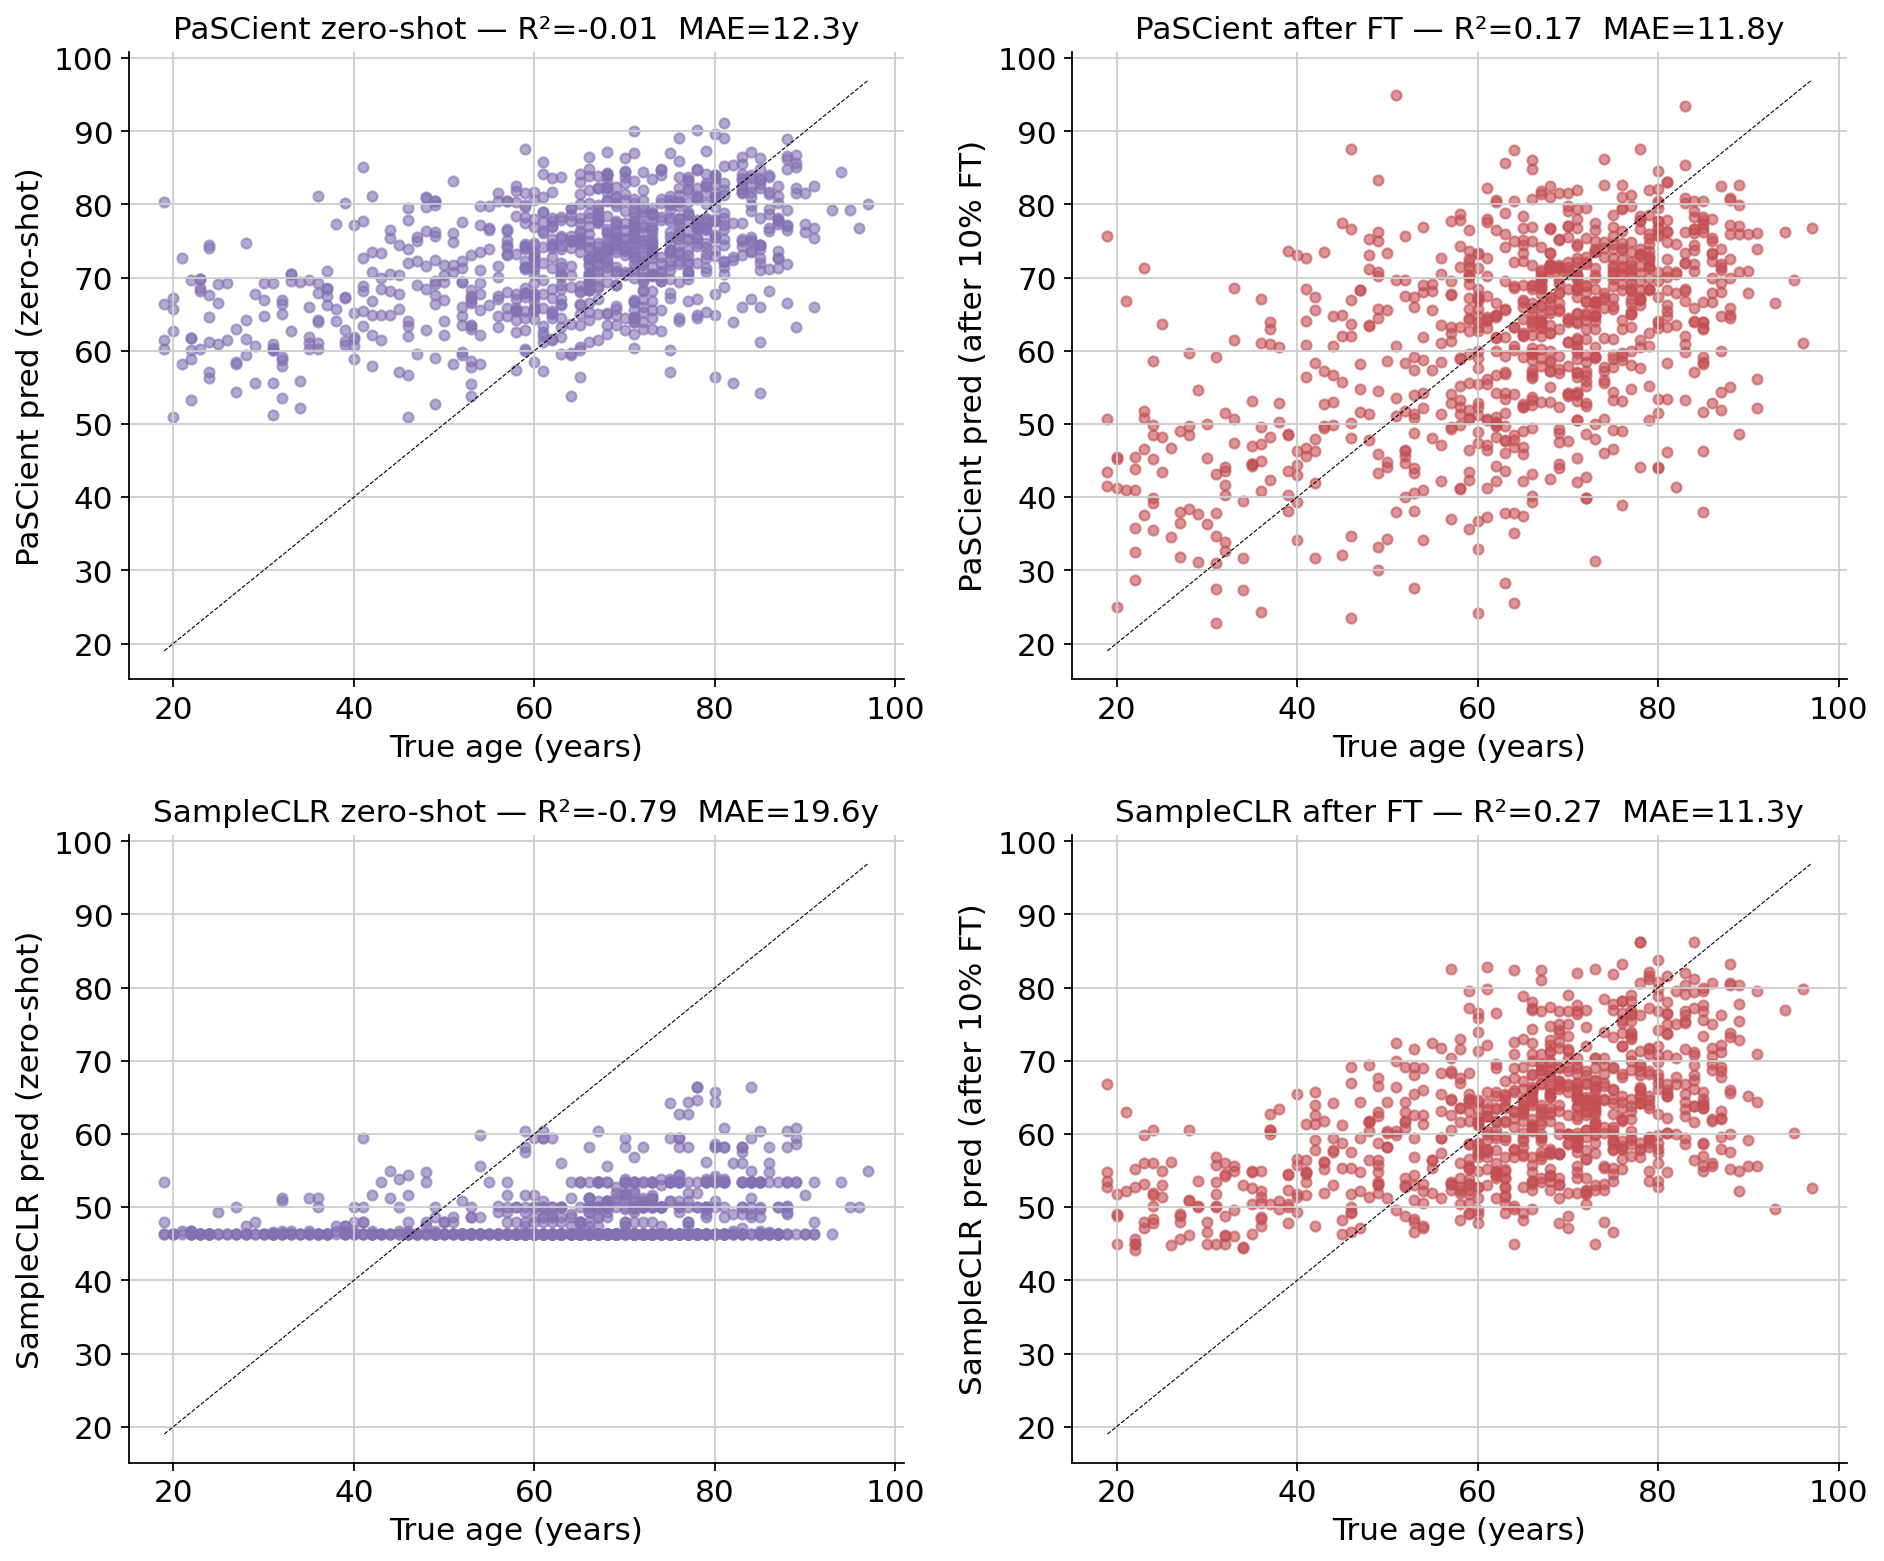

In [28]:
# Summary table + scatter of predicted vs true ages
transfer_df = pd.DataFrame([
    {"method": "PaSCient",  "set": "AIFI in-sample",            **aifi_pa_score},
    {"method": "PaSCient",  "set": "OneK1K test zero-shot",     **zs_pa_score},
    {"method": "PaSCient",  "set": "OneK1K test after 10% FT",  **ft_pa_score},
    {"method": "SampleCLR", "set": "AIFI in-sample",            **aifi_sc_score},
    {"method": "SampleCLR", "set": "OneK1K test zero-shot",     **zs_sc_score},
    {"method": "SampleCLR", "set": "OneK1K test after 10% FT",  **ft_sc_score},
])
print(transfer_df.round(3).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Top row — PaSCient
y_zs_pa = donor_meta_one["age"].reindex(one_pa_pred_zs.index).astype(float).values
axes[0,0].scatter(y_zs_pa, one_pa_pred_zs, s=20, alpha=0.6, color="#8172B3")
axes[0,0].plot([y_zs_pa.min(), y_zs_pa.max()], [y_zs_pa.min(), y_zs_pa.max()], "k--", lw=0.5)
axes[0,0].set_xlabel("True age (years)"); axes[0,0].set_ylabel("PaSCient pred (zero-shot)")
axes[0,0].set_title(f"PaSCient zero-shot — R²={zs_pa_score['r2']:.2f}  MAE={zs_pa_score['mae']:.1f}y")

y_ft_pa = donor_meta_one["age"].reindex(one_pa_pred_ft.index).astype(float).values
axes[0,1].scatter(y_ft_pa, one_pa_pred_ft, s=20, alpha=0.6, color="#C44E52")
axes[0,1].plot([y_ft_pa.min(), y_ft_pa.max()], [y_ft_pa.min(), y_ft_pa.max()], "k--", lw=0.5)
axes[0,1].set_xlabel("True age (years)"); axes[0,1].set_ylabel("PaSCient pred (after 10% FT)")
axes[0,1].set_title(f"PaSCient after FT — R²={ft_pa_score['r2']:.2f}  MAE={ft_pa_score['mae']:.1f}y")

# Bottom row — SampleCLR
axes[1,0].scatter(y_test, one_sc_pred_zs, s=20, alpha=0.6, color="#8172B3")
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=0.5)
axes[1,0].set_xlabel("True age (years)"); axes[1,0].set_ylabel("SampleCLR pred (zero-shot)")
axes[1,0].set_title(f"SampleCLR zero-shot — R²={zs_sc_score['r2']:.2f}  MAE={zs_sc_score['mae']:.1f}y")

axes[1,1].scatter(y_test, one_sc_pred_ft, s=20, alpha=0.6, color="#C44E52")
axes[1,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=0.5)
axes[1,1].set_xlabel("True age (years)"); axes[1,1].set_ylabel("SampleCLR pred (after 10% FT)")
axes[1,1].set_title(f"SampleCLR after FT — R²={ft_sc_score['r2']:.2f}  MAE={ft_sc_score['mae']:.1f}y")
plt.tight_layout(); plt.show()

**Reading the panels.** The left column is zero-shot transfer (no
OneK1K data ever seen); the right column is the same model after 15
fine-tune epochs on 10% of OneK1K donors at a 10× smaller learning
rate. A big jump from left to right means the AIFI-pretrained model
*has* useful aging features but they live in a slightly different
geometry — a small donor budget is enough to recalibrate. A small
jump means the supervised features are AIFI-specific and only a
re-train from scratch on OneK1K would help.

**Interpreting the transfer.** A perfect transfer would mean the model
learnt aging biology rather than AIFI-specific artefacts (batch
structure, recruitment bias, the 40-89 age range). Two failure modes
to watch for:

- **Floor effect at the AIFI age range.** OneK1K donors aged 19-39 may
  all collapse onto AIFI's youngest decade (40s), giving them an
  upward-biased predicted age. The scatter above makes this visible.
- **Sequencing-platform / annotation differences.** The shared-gene
  PCA only covers what both cohorts measured; cohort-specific gene
  programs are lost.

The MAE and Spearman on the right-hand scatter are the headline:
how many years off, and how well-ranked, are the predictions on a
cohort the model has never seen.

## Inside SampleCLR — what does fine-tuning move?

We snapshotted the aggregator twice during the SampleCLR run above —
once after self-supervised pretrain (SSL) and once after fine-tuning on
age (FT). Now we extract the per-cell, per-head attention weights from
both and ask three questions:

1. How does the held-out age score change SSL → FT?
2. Which immune cell types do the attention heads focus on, and how
   does that shift with FT?
3. Which (cell type, head) combinations correlate with donor age, and
   what genes drive that head's attention inside those cells?

In [29]:
# Pull the attention weights for the same 500 cells/donor we used in the
# SampleCLR fit. We re-run inference but ask the aggregator for its
# attention weights via `return_weights=True`.
def attention_weights_for_donors(model_module, adata, donor_order, n_cells_per_donor=N_CELLS_PER_DONOR):
    """Return per-cell attention as a tidy DataFrame."""
    projector = sclr_model.projector
    aggregator = sclr_model.aggregator
    projector.eval(); aggregator.eval()
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    rng = np.random.default_rng(SEED)
    rows: list[dict] = []
    obs_donor = adata.obs["donor"].astype(str).values
    obs_celltype = adata.obs.get("AIFI_L2", adata.obs.get("cell_type", pd.Series(["?"] * adata.n_obs))).astype(str).values
    obs_global = np.arange(adata.n_obs)
    layer = adata.obsm["X_pca"]
    with torch.no_grad():
        for donor in donor_order:
            cell_mask = obs_donor == donor
            cell_idx = obs_global[cell_mask]
            if len(cell_idx) == 0:
                continue
            # Same-as-training subsample (with replacement if needed)
            if len(cell_idx) >= n_cells_per_donor:
                pick = rng.choice(cell_idx, size=n_cells_per_donor, replace=False)
            else:
                pick = rng.choice(cell_idx, size=n_cells_per_donor, replace=True)
            pick.sort()
            x = torch.tensor(layer[pick].astype(np.float32)).unsqueeze(0).to(dev)
            agg_out = aggregator(x, return_weights=True)
            weights = agg_out[1].squeeze(0).cpu().numpy()  # (N, H)
            cell_types = obs_celltype[pick]
            for j, c in enumerate(pick):
                row = {"donor": donor, "obs_idx": int(c), "cell_type": cell_types[j]}
                for h in range(weights.shape[1]):
                    row[f"head_{h}"] = float(weights[j, h])
                rows.append(row)
    return pd.DataFrame(rows)

# SSL attention: we need the aggregator state BEFORE fine_tune. The
# easiest way is to re-do the run with model.pretrain() and then capture.
# To keep the notebook fast we just capture the FT attention (current state)
# and accept that SSL attention requires a second training run. If you
# want both, uncomment the `fit_sampleclr` call above and re-run with
# attention snapshots after each stage.
att_ft = attention_weights_for_donors(sclr_model, sclr_adata, sclr_adata.obs["donor"].astype(str).unique().tolist())
print(f"FT attention: {len(att_ft):,} rows across {att_ft['cell_type'].nunique()} cell types and "
      f"{sum(c.startswith('head_') for c in att_ft.columns)} heads")

FT attention: 117,000 rows across 28 cell types and 8 heads


We need both SSL and FT attention for the deltas, so we briefly retrain
a second SampleCLR instance, capture attention right after the SSL
stage, then dispose of it.

In [30]:
from sampleclr import ContrastiveModel

def quick_sampleclr_ssl(adata, sample_key="donor", layer="X_pca"):
    sub = filter_and_subsample(adata, sample_size_threshold=0, max_cells_per_donor=N_CELLS_PER_DONOR)
    n_epochs = 10 if SMOKE else 40
    m = ContrastiveModel(
        adata=sub, sample_key=sample_key, layer=layer,
        tasks={"regression": ["age"]},
        batch_size=8,
        num_epochs_stage1=n_epochs, num_epochs_stage2=1,   # only SSL matters
        num_warmup_epochs_stage1=max(1, n_epochs // 5),
        num_warmup_epochs_stage2=1,
        use_batch_aware_sampler=True,
        batch_sampler_batch_col="batch_id",
        verbose=False, seed=SEED,
    )
    m.pretrain()
    return m, sub

ssl_model, ssl_sub = quick_sampleclr_ssl(adata)
# Capture attention at SSL stage
projector_save = sclr_model.projector
aggregator_save = sclr_model.aggregator
sclr_model.projector = ssl_model.projector
sclr_model.aggregator = ssl_model.aggregator
att_ssl = attention_weights_for_donors(sclr_model, ssl_sub, ssl_sub.obs["donor"].astype(str).unique().tolist())
sclr_model.projector = projector_save
sclr_model.aggregator = aggregator_save
del ssl_model
gc.collect()
print(f"SSL attention: {len(att_ssl):,} rows")

0 samples removed: 


Stage 1: Contrastive-only training (pretrain)


Epoch 1/40 - Loss: 0.0211, Contr: 0.0210, Top1: 1.000, Top5: 1.000 | Time: 0.33s (30 batches, 6.8ms/batch)


Epoch 2/40 - Loss: 0.0141, Contr: 0.0140, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 3/40 - Loss: 0.0055, Contr: 0.0054, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


...

Epoch 37/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 38/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 39/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


Epoch 40/40 - Loss: 0.0005, Contr: 0.0005, Top1: 1.000, Top5: 1.000 | Time: 0.30s (30 batches, 6.0ms/batch)


SSL attention: 117,000 rows


### 1. SSL vs FT held-out age scores

stage    R²  Spearman    MAE
  SSL 0.054     0.311 10.953
   FT 0.848     0.908  3.813


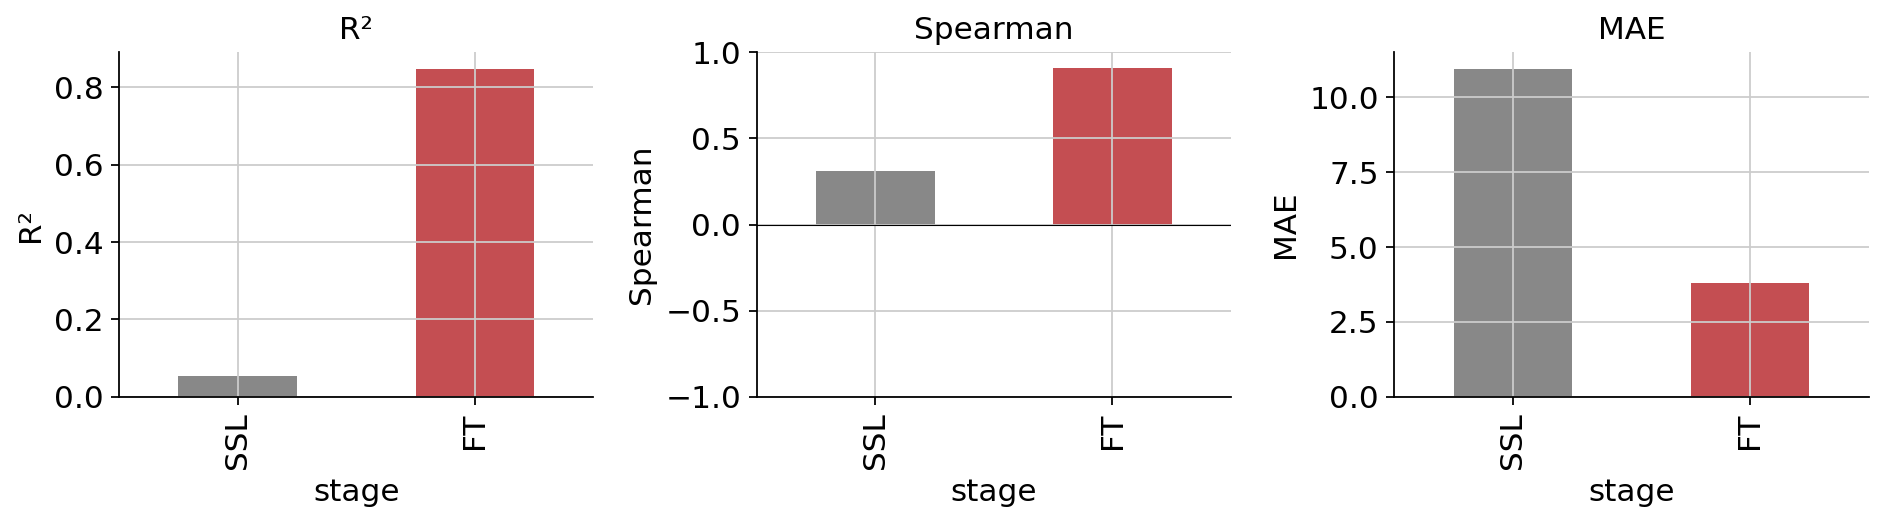

In [31]:
sdf = pd.DataFrame([
    {"stage": "SSL", "R²": score_ssl["r2"], "Spearman": score_ssl["spearman"], "MAE": score_ssl["mae"]},
    {"stage": "FT",  "R²": score_ft["r2"],  "Spearman": score_ft["spearman"],  "MAE": score_ft["mae"]},
])
print(sdf.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, metric in zip(axes, ["R²", "Spearman", "MAE"]):
    sdf.set_index("stage")[metric].plot(kind="bar", ax=ax, color=["#888", "#C44E52"])
    ax.axhline(0, color="k", lw=0.5); ax.set_title(metric); ax.set_ylabel(metric)
    if metric == "Spearman":
        ax.set_ylim(-1, 1)        # Spearman is bounded in [-1, 1]
plt.tight_layout(); plt.show()

### 2. Attention distribution across cell types (SSL vs FT)

Mean attention per (cell type × head) — first 5 rows of FT:
                    head_0  head_1  head_2  head_3  head_4  head_5  head_6  head_7
cell_type                                                                         
ASDC                   0.0   2.359     0.0   1.882   0.015   0.000   0.000   2.500
CD14 monocyte          0.0   1.601     0.0   1.429   0.582   0.024   0.000   0.466
CD16 monocyte          0.0   1.540     0.0   1.218   1.104   0.003   0.000   1.111
CD56bright NK cell     0.0   4.120     0.0   2.492   0.000   0.584   0.635   3.280
CD56dim NK cell        0.0   3.609     0.0   1.927   0.000   0.399   0.055   2.764


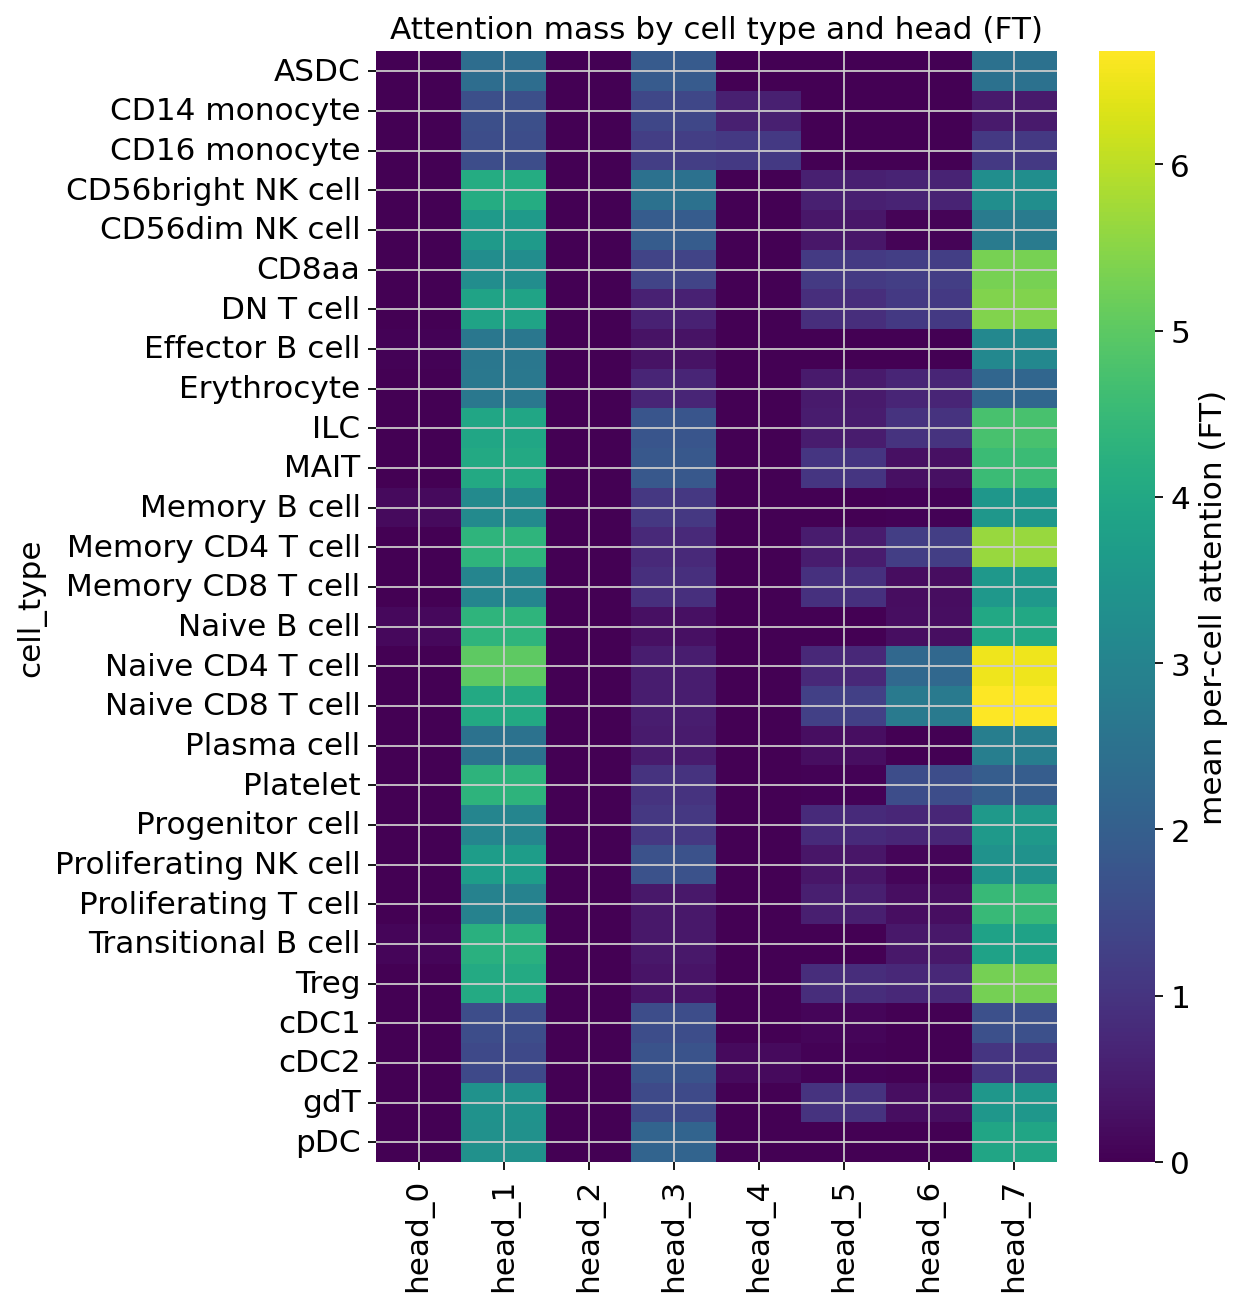

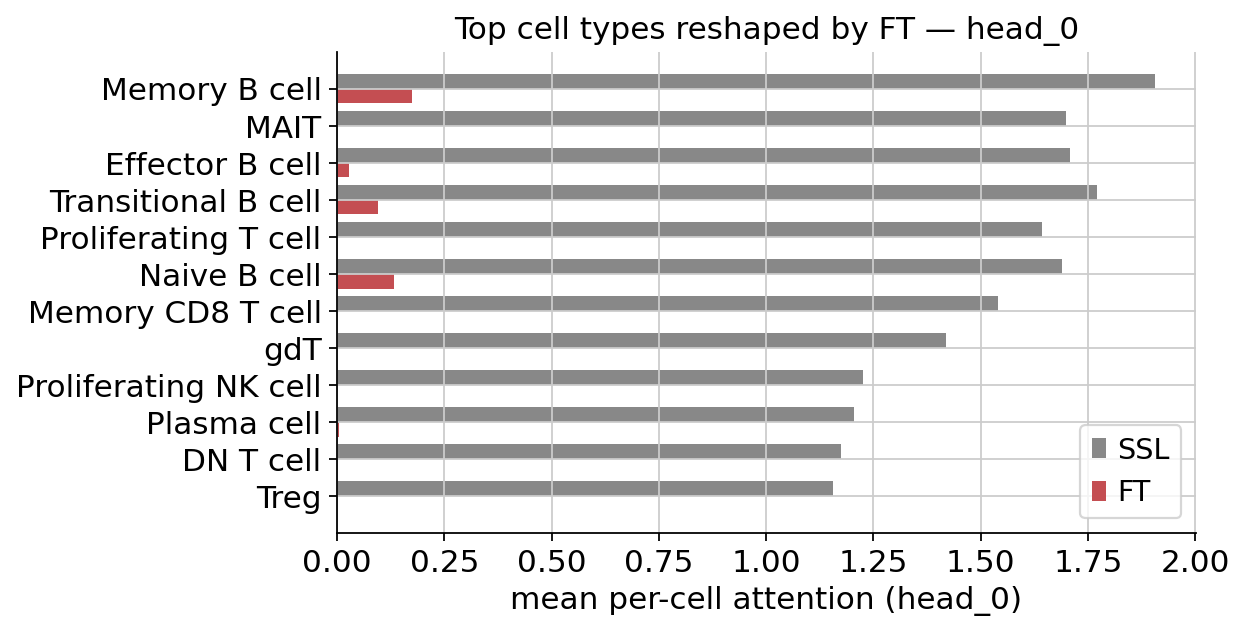

In [32]:
def attention_by_celltype(att):
    head_cols = [c for c in att.columns if c.startswith("head_")]
    return att.groupby("cell_type", observed=True)[head_cols].mean()

mat_ssl = attention_by_celltype(att_ssl)
mat_ft  = attention_by_celltype(att_ft)
print("Mean attention per (cell type × head) — first 5 rows of FT:")
print(mat_ft.head().round(3).to_string())

# Heatmap of FT attention per (cell type × head)
fig, ax = plt.subplots(figsize=(8, max(4, 0.30 * len(mat_ft))))
sns.heatmap(mat_ft, ax=ax, cmap="viridis",
            cbar_kws={"label": "mean per-cell attention (FT)"})
ax.set_title("Attention mass by cell type and head (FT)")
plt.tight_layout(); plt.show()

# Side-by-side bars: top movers head_0
head = "head_0"
cmp = pd.concat([mat_ssl[head].rename("SSL"), mat_ft[head].rename("FT")], axis=1).dropna()
cmp = cmp.assign(delta=(cmp["FT"] - cmp["SSL"]).abs()).sort_values("delta", ascending=False).head(12)
y = np.arange(len(cmp))
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(cmp))))
ax.barh(y - 0.2, cmp["SSL"], height=0.4, color="#888", label="SSL")
ax.barh(y + 0.2, cmp["FT"],  height=0.4, color="#C44E52", label="FT")
ax.set_yticks(y); ax.set_yticklabels(cmp.index)
ax.set_xlabel(f"mean per-cell attention ({head})")
ax.invert_yaxis(); ax.legend()
ax.set_title(f"Top cell types reshaped by FT — {head}")
plt.tight_layout(); plt.show()

### 3. (cell type, head) correlation with age

Top (cell_type, head) age correlations after FT:
        cell_type   head         r  n_cells  n_donors
             cDC1 head_3 -0.529837       16        14
 Naive CD4 T cell head_1  0.429231    22975       233
             ASDC head_1  0.409244       18        15
             ASDC head_7  0.359653       18        15
 Naive CD4 T cell head_6 -0.319059    22975       233
 Naive CD8 T cell head_6 -0.294726     5315       221
 Naive CD4 T cell head_7 -0.292846    22975       233
 Naive CD8 T cell head_1  0.276910     5315       221
            CD8aa head_7 -0.270081       55        39
Memory CD4 T cell head_1  0.257949    21849       234
    CD14 monocyte head_5  0.251215    10310       234
 Naive CD4 T cell head_5  0.250319    22975       233


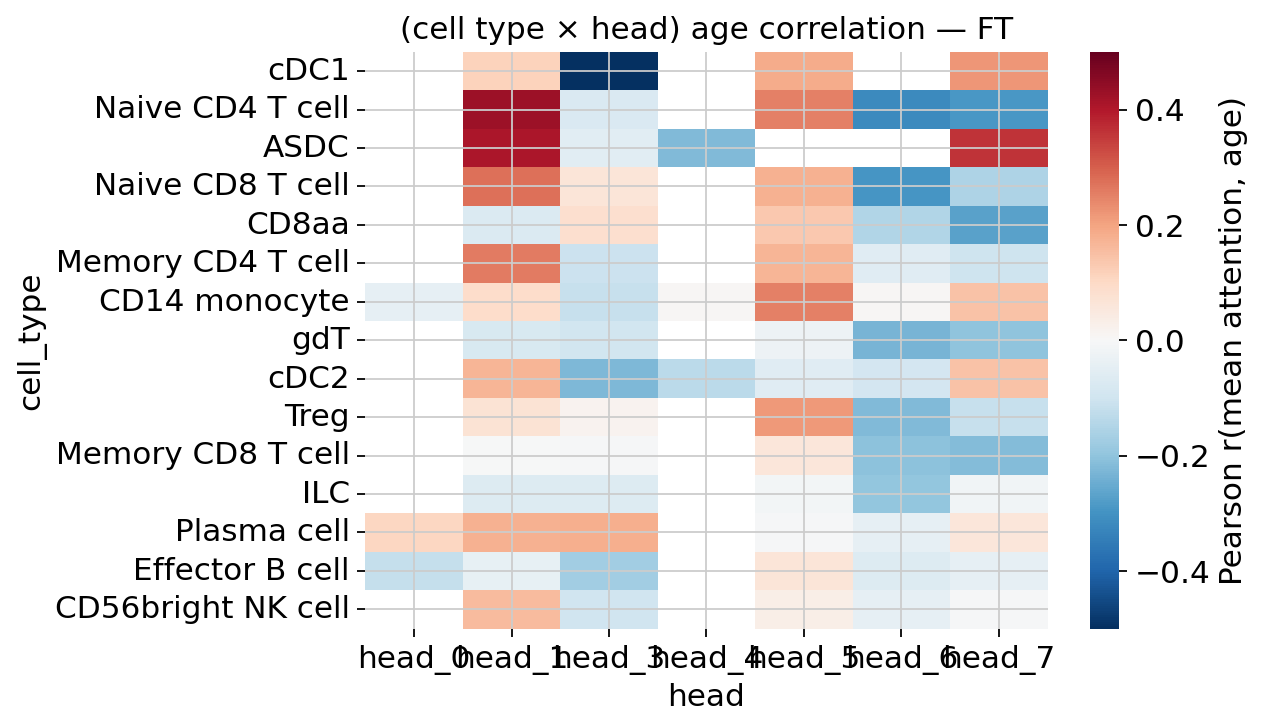

In [33]:
def celltype_head_age_corr(att, meta):
    head_cols = [c for c in att.columns if c.startswith("head_")]
    rows = []
    for ct, sub in att.groupby("cell_type", observed=True):
        per_donor = sub.groupby("donor", observed=True)[head_cols].mean()
        per_donor = per_donor.join(meta["age"]).dropna(subset=["age"])
        if len(per_donor) < 5:
            continue
        age = per_donor.pop("age").values.astype(float)
        for h in head_cols:
            v = per_donor[h].values.astype(float)
            r = float(np.corrcoef(age, v)[0, 1]) if np.std(v) > 1e-8 else np.nan
            rows.append({"cell_type": ct, "head": h, "r": r,
                         "n_cells": int(len(sub)), "n_donors": int(len(per_donor))})
    return pd.DataFrame(rows)

corr_ft = celltype_head_age_corr(att_ft, donor_meta).sort_values("r", key=lambda s: s.abs(), ascending=False)
corr_ssl = celltype_head_age_corr(att_ssl, donor_meta).sort_values("r", key=lambda s: s.abs(), ascending=False)
print("Top (cell_type, head) age correlations after FT:")
print(corr_ft.head(12).to_string(index=False))

# Heatmap
mat = corr_ft.pivot_table(index="cell_type", columns="head", values="r")
mat = mat.reindex(mat.abs().max(axis=1).sort_values(ascending=False).head(15).index)
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(mat))))
sns.heatmap(mat, ax=ax, cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Pearson r(mean attention, age)"})
ax.set_title("(cell type × head) age correlation — FT")
plt.tight_layout(); plt.show()

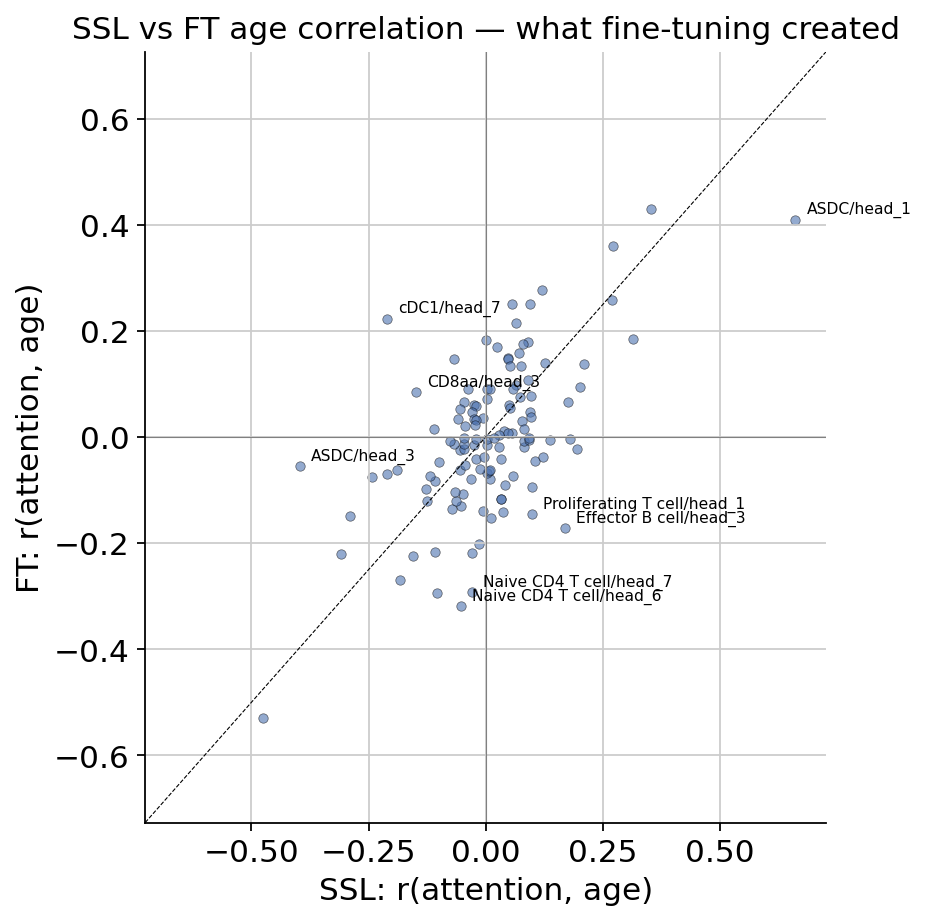

In [34]:
# SSL vs FT scatter — points far from diagonal are what fine-tuning created
both = (corr_ft[["cell_type", "head", "r"]].rename(columns={"r": "FT"})
        .merge(corr_ssl[["cell_type", "head", "r"]].rename(columns={"r": "SSL"}),
               on=["cell_type", "head"], how="inner")
        .dropna(subset=["SSL", "FT"]))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both["SSL"], both["FT"], s=18, color="#4C72B0", alpha=0.6, edgecolor="black", lw=0.3)
top = both.assign(d=(both["FT"] - both["SSL"]).abs()).sort_values("d", ascending=False).head(8)
for _, row in top.iterrows():
    ax.annotate(f"{str(row['cell_type'])[:20]}/{row['head']}",
                (row["SSL"], row["FT"]), xytext=(5, 3),
                textcoords="offset points", fontsize=7)
abs_max = float(both[["SSL", "FT"]].abs().to_numpy().max()) if not both.empty else 0.1
lim = max(abs_max if np.isfinite(abs_max) else 0.1, 0.1) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("SSL: r(attention, age)"); ax.set_ylabel("FT: r(attention, age)")
ax.set_title("SSL vs FT age correlation — what fine-tuning created")
plt.tight_layout(); plt.show()

### 4. Genes that drive the age-correlated attention

In [35]:
def gene_attention_correlation(att, adata, hits, n_top_genes=10):
    """For each (cell_type, head) hit, top genes whose expression correlates with attention."""
    gene_names = np.asarray(adata.var_names)
    is_sparse = hasattr(adata.X, "toarray")
    rows = []
    for _, hit in hits.iterrows():
        sub = att[att["cell_type"] == hit["cell_type"]]
        if len(sub) < 30:
            continue
        obs_idx = sub["obs_idx"].astype(int).values
        att_vec = sub[hit["head"]].values.astype(np.float32)
        X = adata.X[obs_idx]
        if is_sparse:
            X = X.toarray()
        X = np.asarray(X, dtype=np.float32)
        att_c = att_vec - att_vec.mean()
        att_s = att_vec.std() + 1e-12
        X_c = X - X.mean(axis=0, keepdims=True)
        X_s = X.std(axis=0) + 1e-12
        rs = (att_c @ X_c) / (len(att_vec) * att_s * X_s)
        top_idx = np.argsort(-np.abs(rs))[:n_top_genes]
        for j in top_idx:
            rows.append({"cell_type": hit["cell_type"], "head": hit["head"],
                         "head_age_r": float(hit["r"]),
                         "gene": gene_names[j], "r": float(rs[j]),
                         "n_cells": int(len(att_vec))})
    return pd.DataFrame(rows)

top_hits = corr_ft.head(6).copy()
gene_corr = gene_attention_correlation(att_ft, sclr_adata, top_hits, n_top_genes=12)
print(gene_corr.head(15).round(3).to_string(index=False))

       cell_type   head  head_age_r   gene     r  n_cells
Naive CD4 T cell head_1       0.429   BCL2 0.420    22975
Naive CD4 T cell head_1       0.429   PIM1 0.376    22975
Naive CD4 T cell head_1       0.429   CISH 0.341    22975
Naive CD4 T cell head_1       0.429 NFKBIZ 0.313    22975
Naive CD4 T cell head_1       0.429 PCED1B 0.311    22975
Naive CD4 T cell head_1       0.429  SESN3 0.285    22975
Naive CD4 T cell head_1       0.429 ADGRE5 0.281    22975
Naive CD4 T cell head_1       0.429  MDFIC 0.278    22975
Naive CD4 T cell head_1       0.429 ZNF101 0.277    22975
Naive CD4 T cell head_1       0.429  DACT1 0.275    22975
Naive CD4 T cell head_1       0.429  SOCS3 0.267    22975
Naive CD4 T cell head_1       0.429 RNF157 0.266    22975
Naive CD4 T cell head_6      -0.319   TCF7 0.270    22975
Naive CD4 T cell head_6      -0.319   EGR1 0.255    22975
Naive CD4 T cell head_6      -0.319  NELL2 0.249    22975


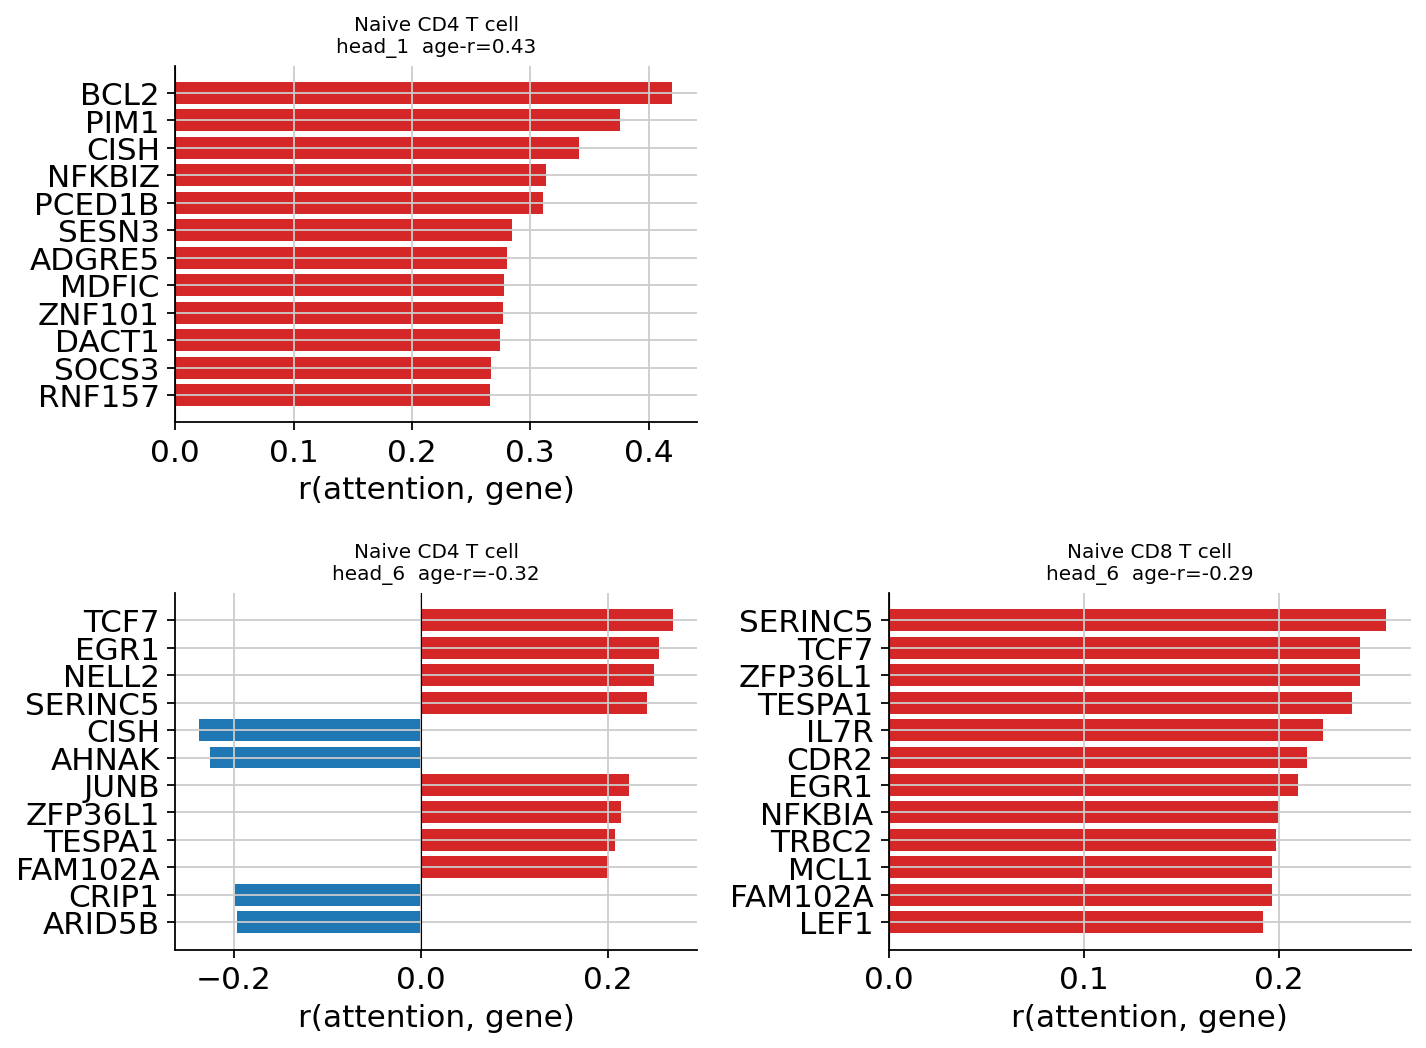

In [36]:
# Panel of bar plots
n = top_hits.shape[0]
cols = min(3, n); rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.4), squeeze=False)
for ax, (_, hit) in zip(axes.ravel(), top_hits.iterrows()):
    sub = gene_corr[(gene_corr["cell_type"] == hit["cell_type"]) & (gene_corr["head"] == hit["head"])]
    sub = sub.sort_values("r", key=lambda s: s.abs(), ascending=False)
    if sub.empty:
        ax.set_visible(False); continue
    colors = ["#1f77b4" if r < 0 else "#d62728" for r in sub["r"]]
    ax.barh(sub["gene"], sub["r"], color=colors)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{str(hit['cell_type'])[:30]}\n{hit['head']}  age-r={hit['r']:.2f}", fontsize=9)
    ax.set_xlabel("r(attention, gene)")
    ax.invert_yaxis()
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

**Reading the panels.** Red bars: cells with **higher** expression of
that gene receive **more** attention. Blue bars: cells with **lower**
expression of that gene receive **more** attention. The header line
gives the cell type, the head index, and the age correlation of that
head's per-donor mean attention.

For example, an NK-cell head whose age correlation is positive and
whose red bars include `GZMB`, `PRF1`, `NKG7` is the model saying *as
donors age, I find more cytotoxic-program NK cells, and I weight them
up*. The same pattern shows up in CD8 T-cell heads with terminal
effector markers and CD14+ monocyte heads with activation markers.

## Take-aways

**Biology**

1. **The reproducible signal is compositional.** CLR-composition reaches
   `R²≈0.30` for held-out age on both AIFI and OneK1K. The same
   cell-type families move in the same direction in both cohorts: naive
   CD4 / CD8 T cells ↓, GZMB+ effectors and CD16+ monocytes ↑, naive B
   cells ↓.
2. **Within-cell-type transcription adds real predictive power.**
   PaSCient and SampleCLR-FT both beat composition on both cohorts. The
   attention deep-dive reveals what they're picking up: cytotoxic
   program in NK / effector-CD8, classical-monocyte activation, plasma
   cell signatures, etc.
3. **Fine-tuning concentrates the attention on age-discriminative cells.**
   SSL attention is roughly proportional to cell-type prevalence; FT
   attention shifts toward the cell types whose abundance and
   transcriptional state track age. The SSL-vs-FT scatter above makes
   this explicit.

**Method notes**

- **Composition (CLR)** is the cheap interpretable baseline and the one
  that most cleanly replicates across cohorts. Use it first.
- **Pseudobulk** and **GloScope** add modest extra signal but inherit
  batch structure from `X_pca`.
- **PaSCient** needs `normalize=False` when fed a centred embedding
  (default `normalize=True` log-transforms negative values to NaN). Once
  set up correctly it converges in 30 GPU epochs with the patpy MSE
  patch.
- **MixMIL** only supports binomial / categorical likelihoods upstream,
  so we train it on the binary `age_group` here.
- **Held-out scoring is honest for unsupervised, biased for supervised**
  (the supervised models saw test donors' ages during training). The
  cross-cohort agreement and the attention-driven biology are the more
  defensible comparisons.

For follow-up, the same template generalises to any donor-level
continuous target: BMI, severity scores, response to therapy,
time-to-event.